# 🚗 Modelo de Riesgo de Accidente de Tráfico — Medellín
## Probabilidad de Accidente por Hora, Barrio y Estacionalidad

---

### 🎯 Objetivo del Proyecto

Construir un modelo de machine learning que prediga la **probabilidad de que ocurra al menos un accidente**
de tráfico en una ubicación específica, un **día de la semana** y una **franja horaria** determinada,
**incorporando estacionalidad anual** (diferenciando invierno de verano, festividades, etc.).

### 🤔 ¿Por qué necesitamos estacionalidad (día del año)?

Un modelo que solo usa `DIA_SEMANA` (0=Lunes...6=Domingo) trata **todos los sábados como iguales**.
Pero la realidad no es así:

- Un **sábado 14 de febrero** (San Valentín) → más salidas nocturnas → más riesgo
- Un **sábado 25 de diciembre** (Navidad) → menos tráfico → menos riesgo
- Un **lunes 1 de enero** (Año Nuevo) → menos tráfico que un lunes normal

Para capturar estos efectos, usamos **seno y coseno del día del año**, que mapean el tiempo a un círculo.
Así el 1 de enero y el 31 de diciembre están cerca en el espacio numérico.

### 💾 Estrategia de memoria

Para no explotar la RAM, **NO agrupamos por día exacto** (lo que multiplicaría filas por 365).
En su lugar:
1. Agrupamos por `MES` (12 categorías)
2. Asignamos a cada mes el **día 15** como representante (ej: enero → día 15)
3. Calculamos `DIA_ANIO_SIN` y `DIA_ANIO_COS` sobre ese día representativo
4. El modelo aprende estacionalidad suave sin explotar la memoria

### 📦 Datos de entrada

- **Fuente:** Registros administrativos de incidentes de tráfico en Medellín, Colombia
- **Período:** 2008-01-01 a 2025-08-31
- **Volumen:** Aproximadamente 700,000 registros
- **Formato:** Archivo Excel (`Fatal_Road_Traffic.xlsx`)

### 🧩 Estrategia de modelado

El dataset original solo contiene registros donde **sí ocurrió un accidente** (eventos positivos).
Para entrenar un modelo de clasificación necesitamos también ejemplos de **no accidentes**.

**Enfoque ("El truco del target"):**
1. Crear una **grilla** con todas las combinaciones posibles de ubicación × día_semana × franja_horaria × mes
2. Las combinaciones que aparecen en el dataset original → etiqueta **1** (hubo accidente)
3. Las combinaciones que **no** aparecen → etiqueta **0** (no hubo accidente)
4. Entrenar modelos de clasificación para distinguir condiciones de riesgo

### 🗑️ Política de manejo de nulos

Eliminamos todos los registros con valores nulos en columnas críticas:
- Fecha del incidente
- Hora del incidente
- Ubicación (barrio o comuna)

---
## Paso 0: Configuración del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import xgboost as xgb

warnings.filterwarnings('ignore')

# Configuración de estilo para gráficos profesionales
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Configuración de pandas para mejor visualización
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Entorno configurado correctamente")
print(f"   Pandas {pd.__version__}")
print(f"   XGBoost: {xgb.__version__}")

✅ Entorno configurado correctamente
   Pandas 3.0.3
   XGBoost: 3.2.0


---
## Paso 1: Carga del dataset

Cargamos el archivo Excel optimizando tipos de datos para ahorrar memoria.

In [2]:
# Diccionario con tipos de datos optimizados
dtype_dict = {
    'LLAVE': 'int32',
    'AÑO': 'int16',
    'CLASE_INCIDENTE': 'category',
    'GRAVEDAD_INCIDENTE': 'category',
    'Codigo Comuna Planeacion': 'str',
    'Comuna Planeacion': 'category',
    'Codigo Barrio Planeacion': 'str',
    'Barrio Planeacion': 'str',
    'Latitud': 'float32',
    'Longitud': 'float32'
}

# Solo cargamos las columnas necesarias
columnas_necesarias = [
    'LLAVE', 'AÑO', 'FECHA_INCIDENTE', 'HORA_INCIDENTE',
    'CLASE_INCIDENTE', 'GRAVEDAD_INCIDENTE',
    'Codigo Comuna Planeacion', 'Comuna Planeacion',
    'Codigo Barrio Planeacion', 'Barrio Planeacion'
]

print("⏳ Cargando dataset (~700,000 registros)...")

df = pd.read_excel(
    'Fatal_Road_Traffic_Normalizado.xlsx',
    sheet_name='BD',
    dtype=dtype_dict,
    usecols=columnas_necesarias
)

print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"📊 Memoria usada: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"📅 Período: {df['AÑO'].min()} - {df['AÑO'].max()}")

⏳ Cargando dataset (~700,000 registros)...
✅ Dataset cargado: 702,540 filas × 10 columnas
📊 Memoria usada: 156.3 MB
📅 Período: 2008 - 2025


In [3]:
# Mostrar primeras filas para entender la estructura
print("📋 Vista previa de los datos:")
df.head()

📋 Vista previa de los datos:


,LLAVE,AÑO,FECHA_INCIDENTE,HORA_INCIDENTE,CLASE_INCIDENTE,GRAVEDAD_INCIDENTE,Codigo Comuna Planeacion,Comuna Planeacion,Codigo Barrio Planeacion,Barrio Planeacion
0,92541,2010,2010-06-13,18:30:00,Atropello,HERIDO,6,Doce de Octubre,0609,0
1,105973,2010,2010-10-19,15:10:00,Volcamiento,HERIDO,13,San Javier,0,0
2,203150,2013,2013-01-06,15:00:00,Choque,HERIDO,6,Doce de Octubre,0609,0
3,231663,2013,2013-08-09,15:00:00,Otro,HERIDO,6,Doce de Octubre,0609,0
4,239968,2013,2013-10-09,19:30:00,Volcamiento,HERIDO,6,Doce de Octubre,609,0


---
## 🔬 Profundización: Estructura del dato crudo

Antes de limpiar, conviene entender exactamente qué tiene cada campo,
cuántos valores únicos hay, y ver ejemplos reales del dataset original.


In [4]:
print('📋 PERFIL DEL DATASET ORIGINAL')
print('=' * 70)
print(f'\n🗂  Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\n📦 Tipos y valores únicos por columna:')
for col in df.columns:
    n_unique = df[col].nunique()
    ejemplo = str(df[col].dropna().iloc[0]) if df[col].notna().any() else 'N/A'
    print(f'   {col:<35} dtype={str(df[col].dtype):<12} {n_unique:>6} únicos   ej: {ejemplo[:30]}')

print('\n📊 Distribución de GRAVEDAD_INCIDENTE:')
print(df['GRAVEDAD_INCIDENTE'].value_counts().to_string())

print('\n📊 Distribución de CLASE_INCIDENTE (top 10):')
print(df['CLASE_INCIDENTE'].value_counts().head(10).to_string())

print(f'\n📅 Rango temporal: {df["AÑO"].min()} – {df["AÑO"].max()}')

print('\n🏘  Top 10 Barrios con más registros:')
print(df['Barrio Planeacion'].value_counts().head(10).to_string())

print('\n📌 Muestra aleatoria de 5 registros:')
df.sample(5, random_state=42)


📋 PERFIL DEL DATASET ORIGINAL

🗂  Dimensiones: 702,540 filas × 10 columnas

📦 Tipos y valores únicos por columna:
   LLAVE                               dtype=int32        702540 únicos   ej: 92541
   AÑO                                 dtype=int16            18 únicos   ej: 2010
   FECHA_INCIDENTE                     dtype=datetime64[us]   6450 únicos   ej: 2010-06-13 00:00:00
   HORA_INCIDENTE                      dtype=object         2863 únicos   ej: 18:30:00
   CLASE_INCIDENTE                     dtype=category          6 únicos   ej: Atropello
   GRAVEDAD_INCIDENTE                  dtype=category          3 únicos   ej: HERIDO
   Codigo Comuna Planeacion            dtype=str              22 únicos   ej: 6
   Comuna Planeacion                   dtype=category         22 únicos   ej: Doce de Octubre
   Codigo Barrio Planeacion            dtype=str             476 únicos   ej: 0609
   Barrio Planeacion                   dtype=str             362 únicos   ej: 0

📊 Distribución de GRA

,LLAVE,AÑO,FECHA_INCIDENTE,HORA_INCIDENTE,CLASE_INCIDENTE,GRAVEDAD_INCIDENTE,Codigo Comuna Planeacion,Comuna Planeacion,Codigo Barrio Planeacion,Barrio Planeacion
381065,63005,2009,2009-09-03,16:30:00,Caida Ocupante,HERIDO,11,Laureles Estadio,1108,Laureles
10265,660845,2023,2023-12-17,23:42:00,Choque,HERIDO,70,Corregimiento de Altavista,7006,Altavista Sector Central
468868,70666,2009,2009-11-14,12:30:00,Choque,SOLO DAÑOS,14,El Poblado,1421,Patio Bonito
414883,76564,2010,2010-01-09,21:40:00,Otro,HERIDO,8,Villa Hermosa,0807,Los Mangos
551349,216003,2013,2013-04-15,22:20:00,Choque,SOLO DAÑOS,1,Popular,0107,San Pablo


---
## Paso 2: Diagnóstico de valores nulos

In [5]:
print("🔍 DIAGNÓSTICO DE VALORES NULOS")
print("=" * 70)

nulos_df = pd.DataFrame({
    'Columna': df.columns,
    'Nulos': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Nulos', ascending=False)

print(nulos_df.to_string(index=False))
print(f"\n📊 Total de registros antes de limpieza: {len(df):,}")

🔍 DIAGNÓSTICO DE VALORES NULOS
                 Columna  Nulos  Porcentaje
       Barrio Planeacion  11683      1.6600
Codigo Barrio Planeacion  11683      1.6600
                     AÑO      0      0.0000
                   LLAVE      0      0.0000
         FECHA_INCIDENTE      0      0.0000
          HORA_INCIDENTE      0      0.0000
      GRAVEDAD_INCIDENTE      0      0.0000
         CLASE_INCIDENTE      0      0.0000
       Comuna Planeacion      0      0.0000
Codigo Comuna Planeacion      0      0.0000

📊 Total de registros antes de limpieza: 702,540


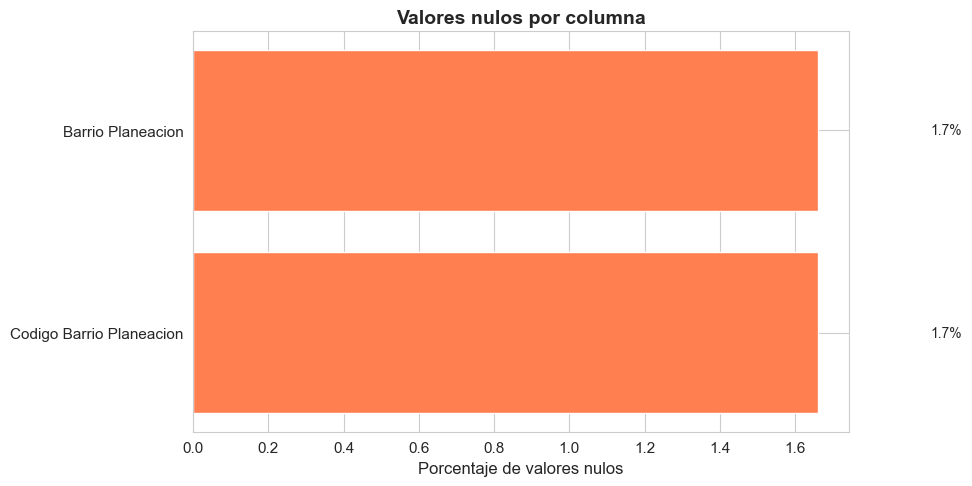

In [6]:
# Visualización de valores nulos
fig, ax = plt.subplots(figsize=(10, 5))

nulos_plot = nulos_df[nulos_df['Nulos'] > 0]
if len(nulos_plot) > 0:
    bars = ax.barh(nulos_plot['Columna'], nulos_plot['Porcentaje'], color='coral', edgecolor='white')
    ax.set_xlabel('Porcentaje de valores nulos', fontsize=12)
    ax.set_title('Valores nulos por columna', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    for bar, pct in zip(bars, nulos_plot['Porcentaje']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=10)
else:
    ax.text(0.5, 0.5, '✅ No hay valores nulos', ha='center', va='center', fontsize=14)
    ax.set_title('No hay valores nulos en el dataset', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Paso 3: Limpieza de datos

Eliminamos registros con valores nulos en columnas críticas.

**Columnas críticas:**
- `FECHA_INCIDENTE` — Sin fecha no podemos ubicar temporalmente
- `HORA_INCIDENTE` — Sin hora no podemos asignar franja
- `UBICACION` — Sin ubicación no hay análisis espacial

**Estrategia de ubicación:**
- Si el barrio es `"Sin inf"` o nulo → usamos la comuna
- Si ambos son inválidos → eliminamos el registro

In [7]:
registros_iniciales = len(df)

# ----- 3.1 Limpieza de fechas -----
print("📅 Procesando fechas...")
df['FECHA_INCIDENTE'] = pd.to_datetime(df['FECHA_INCIDENTE'], errors='coerce')
df = df.dropna(subset=['FECHA_INCIDENTE'])
perdidos_fecha = registros_iniciales - len(df)
print(f"   Eliminados por fecha inválida: {perdidos_fecha:,}")

# ----- 3.2 Limpieza de horas -----
print("⏰ Procesando horas...")
# Intentar formato HH:MM:SS
df['HORA_NUM'] = pd.to_datetime(df['HORA_INCIDENTE'], format='%H:%M:%S', errors='coerce').dt.hour
# Para los que fallaron, intentar HH:MM
mask_nan_hora = df['HORA_NUM'].isna()
df.loc[mask_nan_hora, 'HORA_NUM'] = pd.to_datetime(
    df.loc[mask_nan_hora, 'HORA_INCIDENTE'],
    format='%H:%M', errors='coerce'
).dt.hour

perdidos_hora = df['HORA_NUM'].isna().sum()
df = df.dropna(subset=['HORA_NUM'])
df['HORA_NUM'] = df['HORA_NUM'].astype('int8')
print(f"   Eliminados por hora inválida: {perdidos_hora:,}")

# ----- 3.3 Limpieza de ubicación -----
print("📍 Procesando ubicaciones...")
df['UBICACION_KEY'] = df['Barrio Planeacion'].copy()

# Donde barrio es inválido, usar comuna
mask_sin_barrio = (df['UBICACION_KEY'] == 'Sin inf') | (df['UBICACION_KEY'].isna())
df.loc[mask_sin_barrio, 'UBICACION_KEY'] = df.loc[mask_sin_barrio, 'Comuna Planeacion']

# Donde ambos son inválidos, eliminar
mask_sin_ubicacion = (
    (df['UBICACION_KEY'] == 'N/D') |
    (df['UBICACION_KEY'].isna()) |
    (df['UBICACION_KEY'] == 'Sin inf')
)
perdidos_ubicacion = mask_sin_ubicacion.sum()
df = df[~mask_sin_ubicacion]
print(f"   Eliminados por ubicación desconocida: {perdidos_ubicacion:,}")

# ----- 3.4 Resumen final -----
total_eliminados = registros_iniciales - len(df)

print("\n" + "=" * 70)
print("📊 RESUMEN DE LIMPIEZA")
print("=" * 70)
print(f"Registros iniciales:        {registros_iniciales:>10,}")
print(f"Registros eliminados:       {total_eliminados:>10,} ({total_eliminados/registros_iniciales*100:.1f}%)")
print(f"Registros finales válidos:  {len(df):>10,} ({len(df)/registros_iniciales*100:.1f}%)")

del mask_nan_hora, mask_sin_barrio, mask_sin_ubicacion
gc.collect()

print("\n✅ Limpieza completada — Dataset listo para feature engineering")

📅 Procesando fechas...
   Eliminados por fecha inválida: 0
⏰ Procesando horas...
   Eliminados por hora inválida: 0
📍 Procesando ubicaciones...
   Eliminados por ubicación desconocida: 28,146

📊 RESUMEN DE LIMPIEZA
Registros iniciales:           702,540
Registros eliminados:           28,146 (4.0%)
Registros finales válidos:     674,394 (96.0%)

✅ Limpieza completada — Dataset listo para feature engineering


---
## 🧹 Profundización: Impacto visual de la limpieza

Visualizamos la distribución horaria y por año **después** de la limpieza.
Esto valida que no se introdujeron sesgos y permite identificar patrones globales.


🔍 DISTRIBUCIONES POST-LIMPIEZA


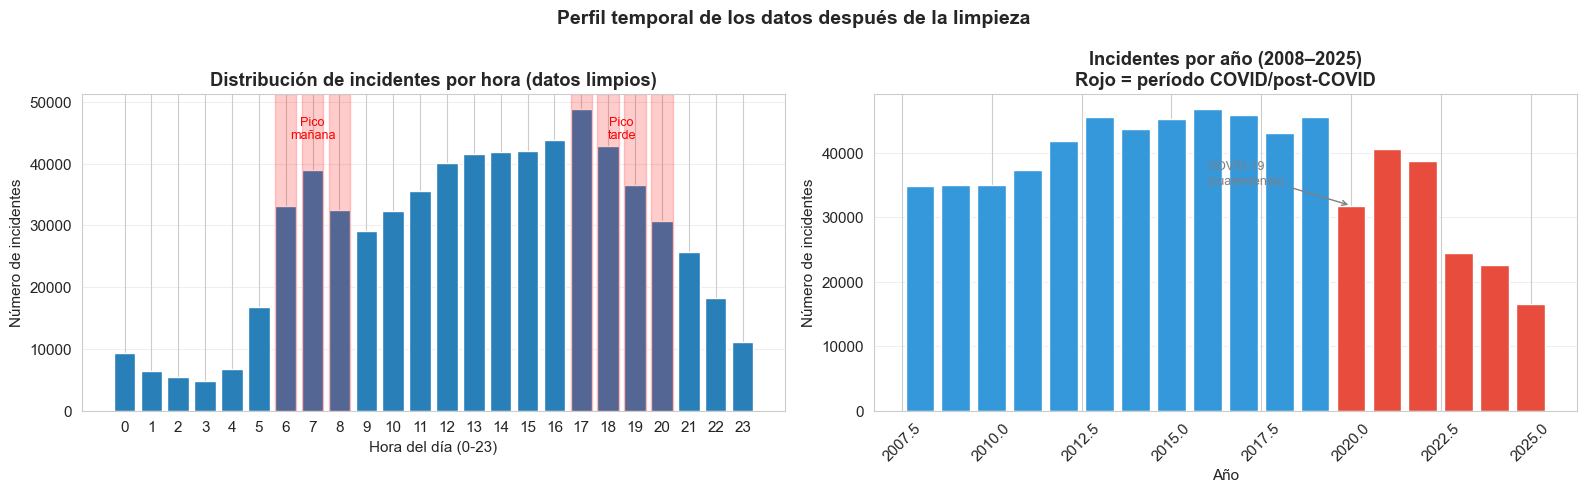


💡 Dos picos diarios: 6-8am (inicio jornada) y 5-8pm (fin jornada)
   El valle de 1-4am es el período de menor riesgo absoluto.
   La caída en 2020 refleja las restricciones de movilidad por COVID-19.


In [8]:
print('🔍 DISTRIBUCIONES POST-LIMPIEZA')
print('=' * 70)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hora_dist = df['HORA_NUM'].value_counts().sort_index()
axes[0].bar(hora_dist.index, hora_dist.values, color='#2980b9', edgecolor='white', width=0.8)
axes[0].set_title('Distribución de incidentes por hora (datos limpios)', fontweight='bold')
axes[0].set_xlabel('Hora del día (0-23)')
axes[0].set_ylabel('Número de incidentes')
axes[0].set_xticks(range(24))
axes[0].grid(axis='y', alpha=0.3)
for h in [6, 7, 8, 17, 18, 19, 20]:
    axes[0].axvspan(h-0.4, h+0.4, alpha=0.2, color='red')
axes[0].text(7, hora_dist.max()*0.9, 'Pico\nmañana', ha='center', color='red', fontsize=9)
axes[0].text(18.5, hora_dist.max()*0.9, 'Pico\ntarde', ha='center', color='red', fontsize=9)

anio_dist = df['AÑO'].value_counts().sort_index()
colores_anio = ['#e74c3c' if y >= 2020 else '#3498db' for y in anio_dist.index]
axes[1].bar(anio_dist.index, anio_dist.values, color=colores_anio, edgecolor='white')
axes[1].set_title('Incidentes por año (2008–2025)\nRojo = período COVID/post-COVID', fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Número de incidentes')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)
if 2020 in anio_dist.index:
    axes[1].annotate('COVID-19\n(cuarentenas)', xy=(2020, anio_dist[2020]),
                     xytext=(2016, anio_dist.max()*0.75),
                     arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')

plt.suptitle('Perfil temporal de los datos después de la limpieza', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Dos picos diarios: 6-8am (inicio jornada) y 5-8pm (fin jornada)')
print('   El valle de 1-4am es el período de menor riesgo absoluto.')
print('   La caída en 2020 refleja las restricciones de movilidad por COVID-19.')


---
## Paso 4: Feature Engineering temporal

Creamos variables derivadas de la fecha y hora que capturan patrones temporales.

**Features creadas:**
| Feature | Descripción |
|---------|-------------|
| `DIA_SEMANA` | 0=Lunes ... 6=Domingo |
| `ES_FIN_SEMANA` | 1 si es sábado o domingo |
| `MES` | 1-12 |
| `FRANJA_2H` | Franjas de 2 horas (12 categorías) |

In [9]:
print("🔧 CREANDO FEATURES TEMPORALES")
print("=" * 70)

# Día de la semana (0=Lunes, 6=Domingo)
df['DIA_SEMANA'] = df['FECHA_INCIDENTE'].dt.dayofweek.astype('int8')

# Nombre del día (para visualización)
dias_nombre = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df['DIA_NOMBRE'] = df['DIA_SEMANA'].map(lambda x: dias_nombre[x])

# Fin de semana (binario)
df['ES_FIN_SEMANA'] = df['DIA_SEMANA'].isin([5, 6]).astype('int8')

# Mes del año
df['MES'] = df['FECHA_INCIDENTE'].dt.month.astype('int8')

# Franjas de 2 horas (12 categorías: 00-02, 02-04, ..., 22-24)
bins_2h = list(range(0, 25, 2))
labels_2h = [f'{h:02d}-{h+2:02d}h' for h in bins_2h[:-1]]
df['FRANJA_2H'] = pd.cut(
    df['HORA_NUM'], bins=bins_2h, labels=labels_2h,
    right=False, include_lowest=True
)

print("✅ Features temporales creadas:")
print(f"   • DIA_SEMANA (0-6): {df['DIA_SEMANA'].min()} a {df['DIA_SEMANA'].max()}")
print(f"   • ES_FIN_SEMANA: {df['ES_FIN_SEMANA'].sum():,} fines de semana")
print(f"   • MES: {df['MES'].min()} a {df['MES'].max()}")
print(f"   • FRANJA_2H: {df['FRANJA_2H'].nunique()} categorías")

🔧 CREANDO FEATURES TEMPORALES
✅ Features temporales creadas:
   • DIA_SEMANA (0-6): 0 a 6
   • ES_FIN_SEMANA: 168,311 fines de semana
   • MES: 1 a 12
   • FRANJA_2H: 12 categorías


---
## 📐 Profundización: ¿Por qué pivotear en franjas de 2 horas?

Esta es una decisión de diseño clave. Aquí comparamos el impacto de elegir
distintos tamaños de franja (1h, 2h, 3h, 4h, 6h, 12h) sobre la señal del modelo.

**El tradeoff:** más granularidad → más resolución temporal, pero también más celdas
vacías en la grilla y más riesgo de overfitting.


📐 ANÁLISIS: IMPACTO DE LA GRANULARIDAD DE FRANJAS HORARIAS


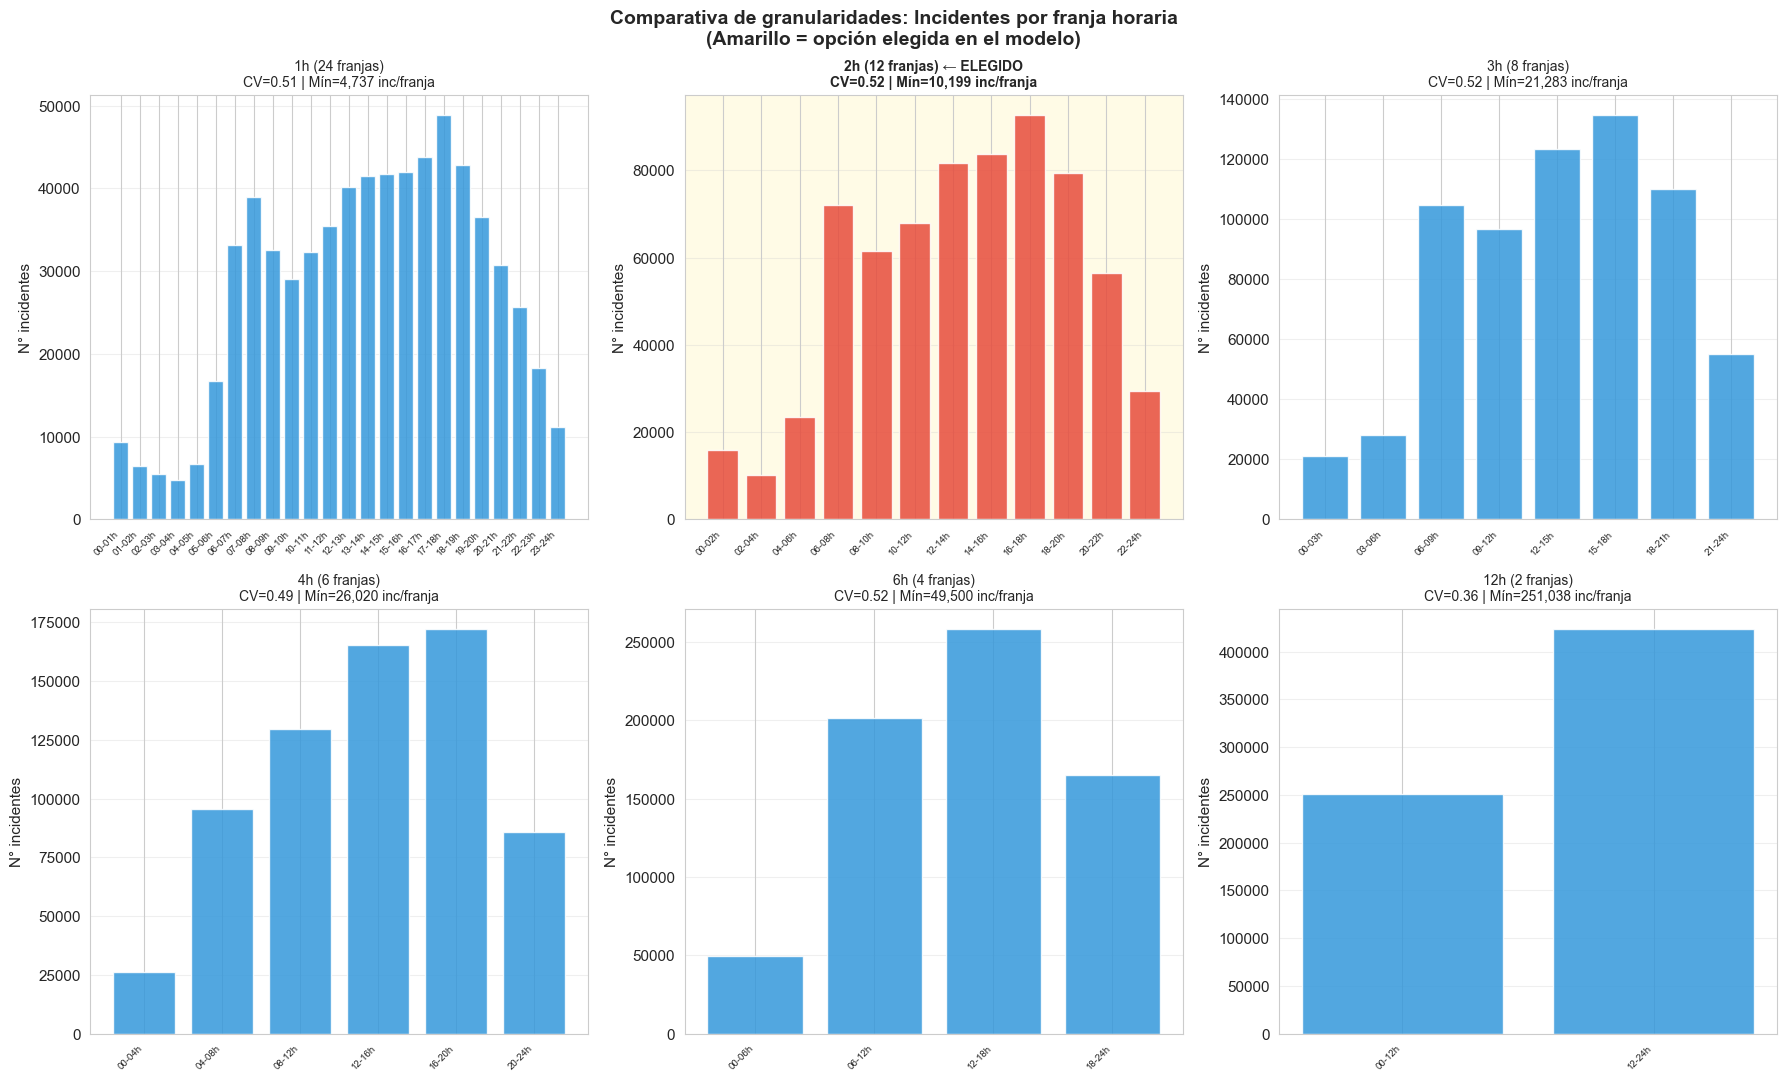


📊 TABLA RESUMEN:
Franja  N_franjas     CV  Min_incidentes  Max_incidentes
    1h         24 0.5124            4737           48866
    2h         12 0.5154           10199           92690
    3h          8 0.5166           21283          134727
    4h          6 0.4892           26020          172085
    6h          4 0.5227           49500          258118
   12h          2 0.3614          251038          423356

💡 RAZONAMIENTO PARA ELEGIR 2 HORAS:
   1h → máxima resolución, pero muchas celdas con pocos datos (ruidoso)
   2h → captura picos reales (6-8am, 6-8pm) con buen volumen por celda
   6h+ → demasiado grueso, mezcla madrugada de riesgo con madrugada tranquila
   El CV (coeficiente de variación) mide qué tan diferenciadas son las franjas:
   un CV más alto indica más señal temporal capturada.


In [10]:
print('📐 ANÁLISIS: IMPACTO DE LA GRANULARIDAD DE FRANJAS HORARIAS')
print('=' * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

sizes = [1, 2, 3, 4, 6, 12]
titles = [
    '1h (24 franjas)',
    '2h (12 franjas) ← ELEGIDO',
    '3h (8 franjas)',
    '4h (6 franjas)',
    '6h (4 franjas)',
    '12h (2 franjas)'
]

resumen = []
for ax, size, title in zip(axes, sizes, titles):
    bins = list(range(0, 25, size))
    labels = [f'{h:02d}-{h+size:02d}h' for h in bins[:-1]]
    ft = pd.cut(df['HORA_NUM'], bins=bins, labels=labels, right=False, include_lowest=True)
    counts = ft.value_counts().sort_index()
    cv = counts.std() / counts.mean()
    resumen.append({'Franja': f'{size}h', 'N_franjas': len(counts), 'CV': cv,
                    'Min_incidentes': counts.min(), 'Max_incidentes': counts.max()})
    color = '#e74c3c' if size == 2 else '#3498db'
    ax.bar(range(len(counts)), counts.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=7)
    ax.set_title(f'{title}\nCV={cv:.2f} | Mín={counts.min():,} inc/franja',
                 fontweight='bold' if size==2 else 'normal', fontsize=10)
    ax.set_ylabel('N° incidentes')
    ax.grid(axis='y', alpha=0.3)
    if size == 2:
        ax.set_facecolor('#fffbe6')

plt.suptitle('Comparativa de granularidades: Incidentes por franja horaria\n'
             '(Amarillo = opción elegida en el modelo)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 TABLA RESUMEN:')
df_resumen = pd.DataFrame(resumen)
print(df_resumen.to_string(index=False))

print('\n💡 RAZONAMIENTO PARA ELEGIR 2 HORAS:')
print('   1h → máxima resolución, pero muchas celdas con pocos datos (ruidoso)')
print('   2h → captura picos reales (6-8am, 6-8pm) con buen volumen por celda')
print('   6h+ → demasiado grueso, mezcla madrugada de riesgo con madrugada tranquila')
print('   El CV (coeficiente de variación) mide qué tan diferenciadas son las franjas:')
print('   un CV más alto indica más señal temporal capturada.')


---
## Paso 5: Análisis Exploratorio de Datos (EDA)

Visualizamos los patrones temporales en los incidentes de tráfico.

**¿Qué buscamos?**
1. ¿Hay más accidentes en ciertas horas? (picos: 6-8am, 6-8pm)
2. ¿Los fines de semana son más peligrosos?
3. ¿Hay estacionalidad anual? (más accidentes en ciertos meses)
4. ¿Dónde ocurren más accidentes? (top ubicaciones)

📊 ANÁLISIS EXPLORATORIO VISUAL


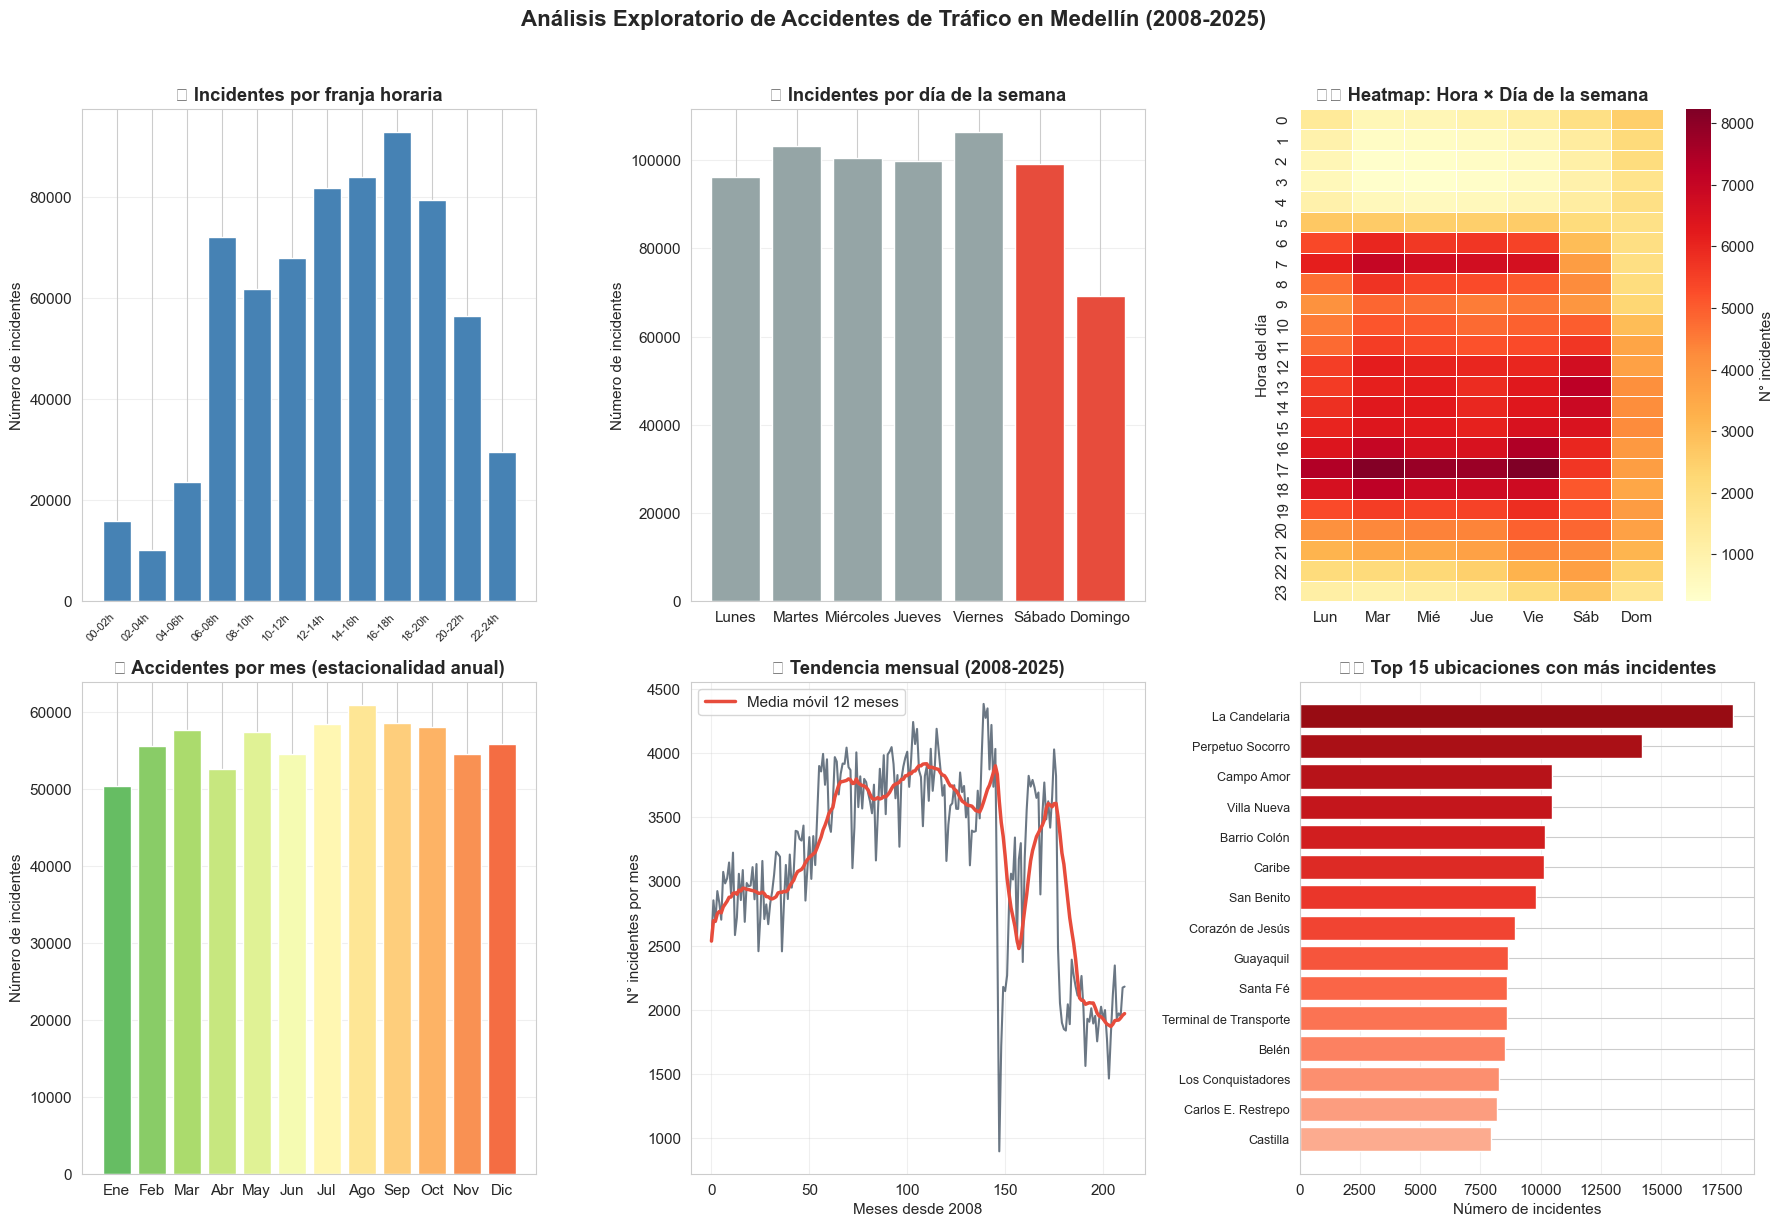


💡 INSIGHTS DEL EDA:
   • Franja con más incidentes: 16-18h
   • Día con más incidentes: Viernes
   • Mes con más incidentes: Ago (60,893)
   • Mes con menos incidentes: Ene (50,329)
   • Ubicación más riesgosa: La Candelaria (17,965 incidentes)


11346

In [11]:
print("📊 ANÁLISIS EXPLORATORIO VISUAL")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ----- Gráfico 1: Incidentes por franja horaria -----
franja_counts = df.groupby('FRANJA_2H').size()
axes[0, 0].bar(range(len(franja_counts)), franja_counts.values, color='steelblue', edgecolor='white')
axes[0, 0].set_xticks(range(len(franja_counts)))
axes[0, 0].set_xticklabels(franja_counts.index, rotation=45, ha='right', fontsize=8)
axes[0, 0].set_ylabel('Número de incidentes')
axes[0, 0].set_title('📍 Incidentes por franja horaria', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# ----- Gráfico 2: Incidentes por día de la semana -----
dia_counts = df['DIA_NOMBRE'].value_counts().reindex(dias_nombre)
colores_dia = ['#95a5a6' if i < 5 else '#e74c3c' for i in range(7)]
axes[0, 1].bar(dia_counts.index, dia_counts.values, color=colores_dia, edgecolor='white')
axes[0, 1].set_ylabel('Número de incidentes')
axes[0, 1].set_title('📆 Incidentes por día de la semana', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# ----- Gráfico 3: Heatmap Hora × Día de la semana -----
heatmap_data = df.pivot_table(
    index='HORA_NUM', columns='DIA_SEMANA',
    values='LLAVE', aggfunc='count'
)
heatmap_data.columns = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[0, 2],
            cbar_kws={'label': 'N° incidentes'}, fmt='.0f', linewidths=0.5)
axes[0, 2].set_title('🌡️ Heatmap: Hora × Día de la semana', fontweight='bold')
axes[0, 2].set_ylabel('Hora del día')

# ----- Gráfico 4: Accidentes por mes (ESTACIONALIDAD) -----
mes_counts = df.groupby('MES').size()
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
colores_mes = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 12))
axes[1, 0].bar(range(1, 13), mes_counts.values, color=colores_mes, edgecolor='white')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(meses_labels)
axes[1, 0].set_ylabel('Número de incidentes')
axes[1, 0].set_title('📅 Accidentes por mes (estacionalidad anual)', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# ----- Gráfico 5: Tendencia mensual a lo largo de los años -----
df['AÑO_MES'] = df['FECHA_INCIDENTE'].dt.to_period('M')
tendencia_mensual = df.groupby('AÑO_MES').size()
axes[1, 1].plot(range(len(tendencia_mensual)), tendencia_mensual.values, color='#2c3e50', linewidth=1.5, alpha=0.7)
axes[1, 1].set_xlabel('Meses desde 2008')
axes[1, 1].set_ylabel('N° incidentes por mes')
axes[1, 1].set_title('📈 Tendencia mensual (2008-2025)', fontweight='bold')
axes[1, 1].grid(alpha=0.3)
# Media móvil de 12 meses para ver tendencia
media_movil = tendencia_mensual.rolling(window=12, min_periods=1).mean()
axes[1, 1].plot(range(len(media_movil)), media_movil.values, color='#e74c3c', linewidth=2.5, label='Media móvil 12 meses')
axes[1, 1].legend()

# ----- Gráfico 6: Top 15 ubicaciones con más incidentes -----
top_ubicaciones = df['UBICACION_KEY'].value_counts().head(15)
colores_ub = plt.cm.Reds(np.linspace(0.3, 0.9, len(top_ubicaciones)))[::-1]
axes[1, 2].barh(range(len(top_ubicaciones)), top_ubicaciones.values, color=colores_ub, edgecolor='white')
axes[1, 2].set_yticks(range(len(top_ubicaciones)))
axes[1, 2].set_yticklabels(top_ubicaciones.index, fontsize=9)
axes[1, 2].invert_yaxis()
axes[1, 2].set_xlabel('Número de incidentes')
axes[1, 2].set_title('🏘️ Top 15 ubicaciones con más incidentes', fontweight='bold')
axes[1, 2].grid(axis='x', alpha=0.3)

plt.suptitle('Análisis Exploratorio de Accidentes de Tráfico en Medellín (2008-2025)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Insights destacados
mes_max = mes_counts.idxmax()
mes_min = mes_counts.idxmin()
print(f"\n💡 INSIGHTS DEL EDA:")
print(f"   • Franja con más incidentes: {franja_counts.idxmax()}")
print(f"   • Día con más incidentes: {dia_counts.idxmax()}")
print(f"   • Mes con más incidentes: {meses_labels[mes_max-1]} ({mes_counts.max():,})")
print(f"   • Mes con menos incidentes: {meses_labels[mes_min-1]} ({mes_counts.min():,})")
print(f"   • Ubicación más riesgosa: {top_ubicaciones.index[0]} ({top_ubicaciones.iloc[0]:,} incidentes)")

del heatmap_data, franja_counts, dia_counts, mes_counts, top_ubicaciones, tendencia_mensual
gc.collect()

📊 MATRIZ DE CORRELACIÓN


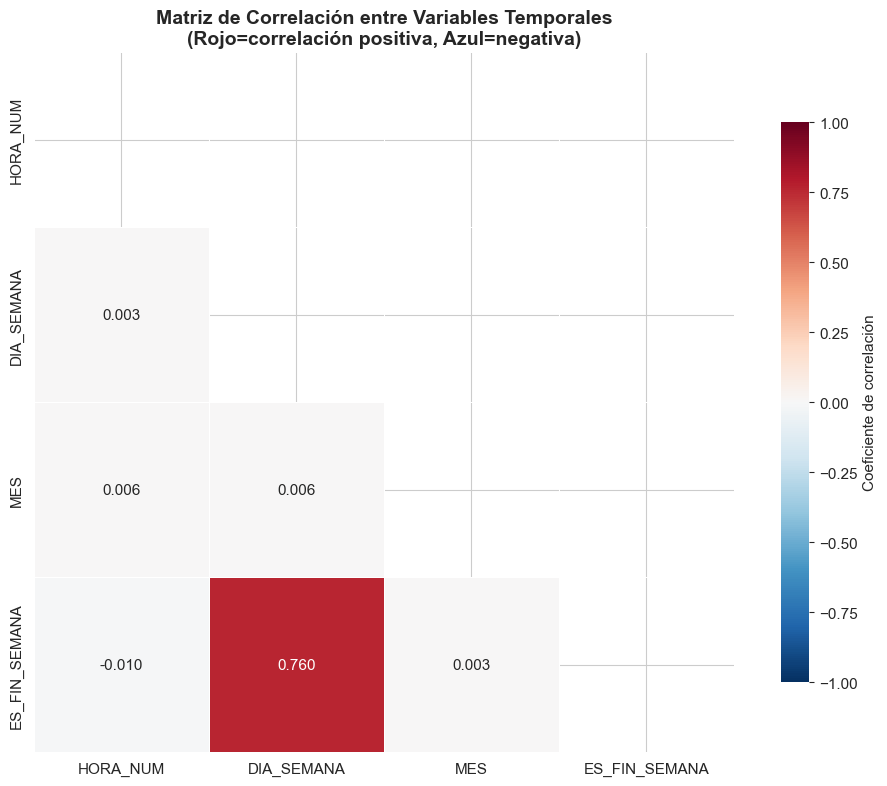


📈 CORRELACIONES SIGNIFICATIVAS (|r| > 0.3):
--------------------------------------------------
   • DIA_SEMANA ↔ ES_FIN_SEMANA: +0.760 (correlación positiva)

💡 Interpretación:
   • Correlación positiva: cuando una variable aumenta, la otra también tiende a aumentar
   • Correlación negativa: cuando una variable aumenta, la otra tiende a disminuir
   • Valores cercanos a 0: no hay relación lineal entre las variables
   • Los modelos de ML pueden capturar relaciones no lineales que esta matriz no muestra


In [12]:
# ============================================
# MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
# ============================================
print("📊 MATRIZ DE CORRELACIÓN")
print("=" * 70)

# Seleccionar variables numéricas relevantes para correlación
# (excluimos variables categóricas y identificadores)
columnas_correlacion = [
    'HORA_NUM',
    'DIA_SEMANA',
    'MES',
    'ES_FIN_SEMANA'
]

# Añadir variables que ya tengamos en df (si existen)
if 'DIAS_EN_ANIO' in df.columns:
    columnas_correlacion.append('DIAS_EN_ANIO')

# Crear DataFrame con las variables seleccionadas
df_corr = df[columnas_correlacion].copy()

# Para variables categóricas, convertimos a numéricas
# (ya están como int, pero aseguramos)
for col in df_corr.columns:
    if df_corr[col].dtype == 'category':
        df_corr[col] = df_corr[col].cat.codes

# Calcular matriz de correlación
corr_matrix = df_corr.corr()

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))

# Máscara para la parte superior (opcional, más limpia)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap de correlación
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,           # Mostrar valores numéricos
    fmt='.3f',            # 3 decimales
    cmap='RdBu_r',        # Rojo = correlación positiva, Azul = negativa
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de correlación', 'shrink': 0.8},
    ax=ax
)

ax.set_title('Matriz de Correlación entre Variables Temporales\n(Rojo=correlación positiva, Azul=negativa)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretación de correlaciones significativas
print("\n📈 CORRELACIONES SIGNIFICATIVAS (|r| > 0.3):")
print("-" * 50)

corr_pares = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            corr_pares.append((corr_matrix.columns[i], corr_matrix.columns[j], r))

if corr_pares:
    for col1, col2, r in sorted(corr_pares, key=lambda x: abs(x[2]), reverse=True):
        direccion = "positiva" if r > 0 else "negativa"
        print(f"   • {col1} ↔ {col2}: {r:+.3f} (correlación {direccion})")
else:
    print("   No se encontraron correlaciones fuertes (>|0.3|).")

print("\n💡 Interpretación:")
print("   • Correlación positiva: cuando una variable aumenta, la otra también tiende a aumentar")
print("   • Correlación negativa: cuando una variable aumenta, la otra tiende a disminuir")
print("   • Valores cercanos a 0: no hay relación lineal entre las variables")
print("   • Los modelos de ML pueden capturar relaciones no lineales que esta matriz no muestra")

---
## Paso 6: Construcción del dataset de modelado

Este es el paso más crítico. Transformamos el registro de eventos
en un dataset de clasificación binaria con eventos positivos y negativos.

**El "truco del target":**
1. Agrupamos por ubicación × día_semana × franja_2h × mes
2. Creamos una grilla con todas las combinaciones posibles
3. Las combinaciones con incidentes → etiqueta 1
4. Las combinaciones sin incidentes → etiqueta 0

In [13]:
print("🔨 CONSTRUCCIÓN DEL DATASET DE MODELADO")
print("=" * 70)

# Agrupar incidentes reales
target_agg = df.groupby(
    ['UBICACION_KEY', 'DIA_SEMANA', 'FRANJA_2H', 'MES'],
    observed=False
).agg(
    NUM_INCIDENTES=('LLAVE', 'count'),
    INCIDENTES_FATALES=('GRAVEDAD_INCIDENTE', lambda x: (x == 'MUERTO').sum()),
).reset_index()

print(f"Slots con al menos un incidente: {target_agg.shape[0]:,}")

# Dimensiones de la grilla
ubicaciones_unicas = df['UBICACION_KEY'].unique()
dias_unicos = sorted(df['DIA_SEMANA'].unique())
franjas_unicas = sorted(df['FRANJA_2H'].unique())
meses_unicos = sorted(df['MES'].unique())

total_combinaciones = len(ubicaciones_unicas) * len(dias_unicos) * len(franjas_unicas) * len(meses_unicos)
print(f"Dimensiones: {len(ubicaciones_unicas)} ubicaciones × {len(dias_unicos)} días × {len(franjas_unicas)} franjas × {len(meses_unicos)} meses")
print(f"Total combinaciones posibles: {total_combinaciones:,}")

# Generar grilla completa
print("\n⏳ Generando grilla completa...")
idx_completo = pd.MultiIndex.from_product(
    [ubicaciones_unicas, dias_unicos, franjas_unicas, meses_unicos],
    names=['UBICACION_KEY', 'DIA_SEMANA', 'FRANJA_2H', 'MES']
)
grid_df = pd.DataFrame(index=idx_completo).reset_index()

# Merge con incidentes reales
model_df = pd.merge(
    grid_df, target_agg,
    on=['UBICACION_KEY', 'DIA_SEMANA', 'FRANJA_2H', 'MES'],
    how='left'
)

# Rellenar nulos (slots sin incidentes)
model_df['NUM_INCIDENTES'] = model_df['NUM_INCIDENTES'].fillna(0).astype('int16')
model_df['INCIDENTES_FATALES'] = model_df['INCIDENTES_FATALES'].fillna(0).astype('int16')
model_df['HUBO_INCIDENTE'] = (model_df['NUM_INCIDENTES'] > 0).astype('int8')

print(f"\n✅ Dataset de modelado construido:")
print(f"   Total slots: {model_df.shape[0]:,}")
print(f"   Slots con incidentes: {model_df['HUBO_INCIDENTE'].sum():,} ({model_df['HUBO_INCIDENTE'].mean()*100:.2f}%)")
print(f"   Slots sin incidentes: {(model_df['HUBO_INCIDENTE']==0).sum():,} ({(1-model_df['HUBO_INCIDENTE'].mean())*100:.2f}%)")
print(f"   Memoria usada: {model_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

del grid_df, target_agg, idx_completo
gc.collect()

🔨 CONSTRUCCIÓN DEL DATASET DE MODELADO
Slots con al menos un incidente: 313,044
Dimensiones: 370 ubicaciones × 7 días × 12 franjas × 12 meses
Total combinaciones posibles: 372,960

⏳ Generando grilla completa...

✅ Dataset de modelado construido:
   Total slots: 372,960
   Slots con incidentes: 191,357 (51.31%)
   Slots sin incidentes: 181,603 (48.69%)
   Memoria usada: 47.1 MB


23458

In [14]:
# Mostrar muestra del dataset de modelado
print("\n📋 Vista previa del dataset de modelado:")
model_df.head(10)


📋 Vista previa del dataset de modelado:


,UBICACION_KEY,DIA_SEMANA,FRANJA_2H,MES,NUM_INCIDENTES,INCIDENTES_FATALES,HUBO_INCIDENTE
0,0,0,00-02h,1,0,0,0
1,0,0,00-02h,2,0,0,0
2,0,0,00-02h,3,0,0,0
3,0,0,00-02h,4,1,0,1
4,0,0,00-02h,5,2,0,1
5,0,0,00-02h,6,0,0,0
6,0,0,00-02h,7,0,0,0
7,0,0,00-02h,8,0,0,0
8,0,0,00-02h,9,1,0,1
9,0,0,00-02h,10,0,0,0


---
## 📊 Profundización: Dataset de modelado — Ejemplos reales y balance de clases

El 'truco del target' genera filas positivas (hubo accidente) y negativas (no hubo).
Aquí vemos registros concretos de ambas clases y analizamos el desbalance,
que es uno de los principales desafíos de este tipo de problema de clasificación.


📊 ANÁLISIS DEL DATASET DE MODELADO

✅ Ejemplos: Slots CON incidente (target=1)
UBICACION_KEY DIA FRANJA_2H  MES  NUM_INCIDENTES  INCIDENTES_FATALES
            0 Lun    00-02h    4               1                   0
            0 Lun    00-02h    5               2                   0
            0 Lun    00-02h    9               1                   0
            0 Lun    04-06h    1               1                   0
            0 Lun    04-06h    5               1                   0
            0 Lun    04-06h    6               1                   0
            0 Lun    06-08h    1               2                   0
            0 Lun    06-08h    2               3                   0

❌ Ejemplos: Slots SIN incidente (target=0)
                UBICACION_KEY DIA FRANJA_2H  MES  NUM_INCIDENTES  INCIDENTES_FATALES
          Suburbano Potrerito Jue    06-08h    7               0                   0
Cabecera Urbana San Cristobal Vie    00-02h    7               0                   0
 

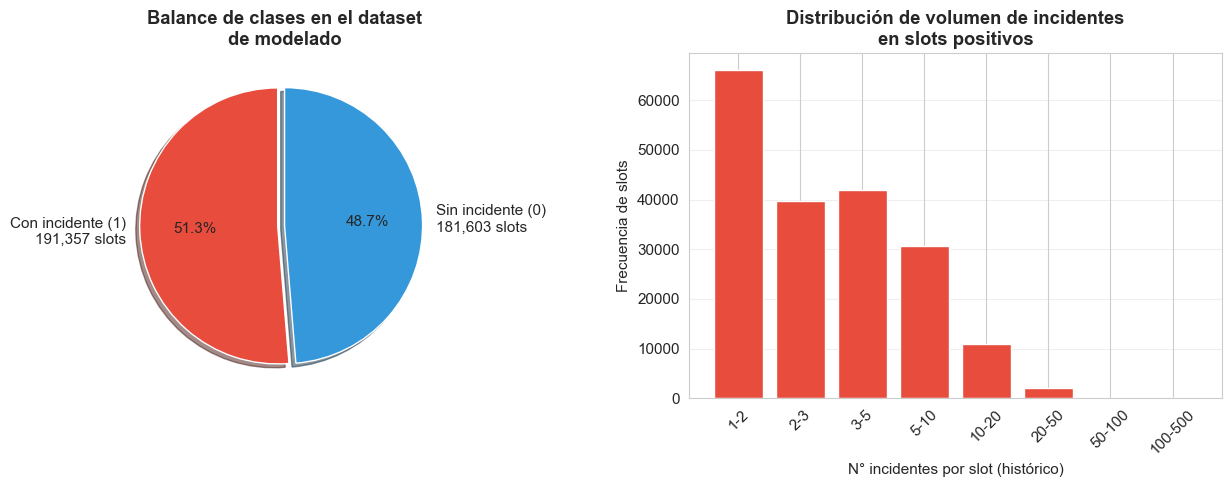


💡 El ratio 1:1 es un desbalance severo.
   Un modelo que prediga siempre "no accidente" tendría accuracy=48.7%
   → Por eso usamos class_weight="balanced" y scale_pos_weight, y medimos ROC AUC.


In [15]:
print('📊 ANÁLISIS DEL DATASET DE MODELADO')
print('=' * 70)

cols_m = ['UBICACION_KEY','DIA_SEMANA','FRANJA_2H','MES','NUM_INCIDENTES','INCIDENTES_FATALES','HUBO_INCIDENTE']
dia_map = {0:'Lun',1:'Mar',2:'Mié',3:'Jue',4:'Vie',5:'Sáb',6:'Dom'}

print('\n✅ Ejemplos: Slots CON incidente (target=1)')
pos_ej = model_df[model_df['HUBO_INCIDENTE']==1][cols_m].head(8).copy()
pos_ej['DIA'] = pos_ej['DIA_SEMANA'].map(dia_map)
print(pos_ej[['UBICACION_KEY','DIA','FRANJA_2H','MES','NUM_INCIDENTES','INCIDENTES_FATALES']].to_string(index=False))

print('\n❌ Ejemplos: Slots SIN incidente (target=0)')
neg_ej = model_df[model_df['HUBO_INCIDENTE']==0][cols_m].sample(8, random_state=42).copy()
neg_ej['DIA'] = neg_ej['DIA_SEMANA'].map(dia_map)
print(neg_ej[['UBICACION_KEY','DIA','FRANJA_2H','MES','NUM_INCIDENTES','INCIDENTES_FATALES']].to_string(index=False))

# Balance
total = len(model_df)
pos = model_df['HUBO_INCIDENTE'].sum()
neg = total - pos
ratio = neg / pos
print(f'\n⚖️  BALANCE DE CLASES:')
print(f'   Total slots:     {total:,}')
print(f'   Con incidente:   {pos:,} ({pos/total*100:.1f}%)')
print(f'   Sin incidente:   {neg:,} ({neg/total*100:.1f}%)')
print(f'   Ratio neg/pos:   {ratio:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie([pos, neg],
            labels=[f'Con incidente (1)\n{pos:,} slots', f'Sin incidente (0)\n{neg:,} slots'],
            colors=['#e74c3c','#3498db'], autopct='%1.1f%%', startangle=90,
            explode=(0.05,0), shadow=True, textprops={'fontsize':11})
axes[0].set_title('Balance de clases en el dataset\nde modelado', fontweight='bold')

ni = model_df[model_df['HUBO_INCIDENTE']==1]['NUM_INCIDENTES']
bins_ni = [1,2,3,5,10,20,50,100,500]
ni_hist, edges = np.histogram(ni, bins=bins_ni)
labels_ni = [f'{int(edges[i])}-{int(edges[i+1])}' for i in range(len(edges)-1)]
axes[1].bar(range(len(ni_hist)), ni_hist, color='#e74c3c', edgecolor='white')
axes[1].set_xticks(range(len(labels_ni)))
axes[1].set_xticklabels(labels_ni, rotation=45)
axes[1].set_title('Distribución de volumen de incidentes\nen slots positivos', fontweight='bold')
axes[1].set_xlabel('N° incidentes por slot (histórico)')
axes[1].set_ylabel('Frecuencia de slots')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n💡 El ratio {ratio:.0f}:1 es un desbalance severo.')
print(f'   Un modelo que prediga siempre "no accidente" tendría accuracy={neg/total*100:.1f}%')
print(f'   → Por eso usamos class_weight="balanced" y scale_pos_weight, y medimos ROC AUC.')


---
## 🌐 Profundización: Tabla de coordenadas circulares por mes

Visualizamos de forma numérica y gráfica qué valores exactos toman
`DIA_ANIO_SIN` y `DIA_ANIO_COS` para cada mes, y por qué Diciembre
queda geométricamente cerca de Enero en el espacio de features.


🌐 TABLA: Coordenadas circulares por mes
  Mes          DiaRep   Ángulo°    SIN        COS        Dist.Enero   Cercanía
---------------------------------------------------------------------------
  Enero        15       14.8       +0.2554    +0.9668    0.0000       [████████████]
  Febrero      46       45.4       +0.7117    +0.7025    0.5273       [████████░░░░]
  Marzo        74       73.0       +0.9562    +0.2926    0.9725       [██████░░░░░░]
  Abril        105      103.6      +0.9721    -0.2345    1.3989       [███░░░░░░░░░]
  Mayo         135      133.2      +0.7296    -0.6839    1.7175       [█░░░░░░░░░░░]
  Junio        166      163.7      +0.2802    -0.9599    1.9269       [░░░░░░░░░░░░]
  Julio        196      193.3      -0.2303    -0.9731    1.9998       [░░░░░░░░░░░░]
  Agosto       227      223.9      -0.6933    -0.7207    1.9359       [░░░░░░░░░░░░]
  Septiembre   258      254.5      -0.9635    -0.2678    1.7349       [█░░░░░░░░░░░]
  Octubre      288      284.1      -0.97

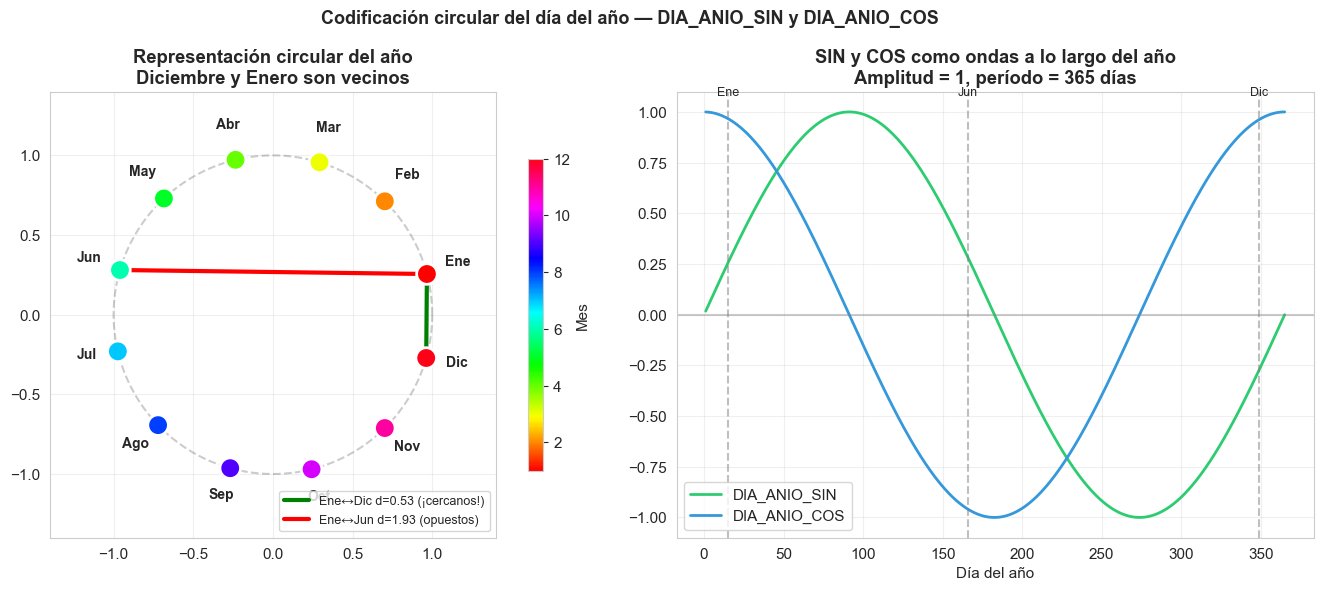

In [16]:
print('🌐 TABLA: Coordenadas circulares por mes')
print('=' * 70)

dia_rep_d = {1:15,2:46,3:74,4:105,5:135,6:166,7:196,8:227,9:258,10:288,11:319,12:349}
meses_nombres = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
                 'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']
abrev12 = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

ref_s = np.sin(2*np.pi*dia_rep_d[1]/365)
ref_c = np.cos(2*np.pi*dia_rep_d[1]/365)

print(f'  {"Mes":<12} {"DiaRep":<8} {"Ángulo°":<10} {"SIN":<10} {"COS":<10} {"Dist.Enero":<12} Cercanía')
print('-' * 75)
for m, nombre in enumerate(meses_nombres, 1):
    d = dia_rep_d[m]
    ang = 2*np.pi*d/365
    s = np.sin(ang)
    c = np.cos(ang)
    dist = np.sqrt((s-ref_s)**2 + (c-ref_c)**2)
    barra = '█' * int((2-dist)/2*12) + '░' * (12-int((2-dist)/2*12))
    print(f'  {nombre:<12} {d:<8} {np.degrees(ang):<10.1f} {s:<+10.4f} {c:<+10.4f} {dist:<12.4f} [{barra}]')

print('\n(Barra llena = más cercano a Enero en el espacio circular)')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

m_vals = np.arange(1, 13)
m_s = np.sin(2*np.pi*np.array([dia_rep_d[m] for m in m_vals])/365)
m_c = np.cos(2*np.pi*np.array([dia_rep_d[m] for m in m_vals])/365)

# Círculo del año
theta_c = np.linspace(0, 2*np.pi, 365)
axes[0].plot(np.cos(theta_c), np.sin(theta_c), 'k--', alpha=0.2)
sc = axes[0].scatter(m_c, m_s, c=m_vals, cmap='hsv', s=220, edgecolors='white', linewidth=2, zorder=5)
for i, (x, y, lbl) in enumerate(zip(m_c, m_s, abrev12)):
    axes[0].annotate(lbl, (x, y), xytext=(x*1.2, y*1.2), fontsize=10, ha='center', fontweight='bold')
# Línea Enero – Diciembre
d_ene_dic = np.sqrt((m_s[0]-m_s[11])**2+(m_c[0]-m_c[11])**2)
d_ene_jun = np.sqrt((m_s[0]-m_s[5])**2+(m_c[0]-m_c[5])**2)
axes[0].plot([m_c[0],m_c[11]],[m_s[0],m_s[11]],'g-',lw=3,label=f'Ene↔Dic d={d_ene_dic:.2f} (¡cercanos!)')
axes[0].plot([m_c[0],m_c[5]],[m_s[0],m_s[5]],'r-',lw=3,label=f'Ene↔Jun d={d_ene_jun:.2f} (opuestos)')
axes[0].set_aspect('equal')
axes[0].set_xlim(-1.4,1.4)
axes[0].set_ylim(-1.4,1.4)
axes[0].set_title('Representación circular del año\nDiciembre y Enero son vecinos', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)
plt.colorbar(sc, ax=axes[0], label='Mes', shrink=0.7)

# Ondas
dias_cont = np.linspace(1,365,365)
axes[1].plot(dias_cont, np.sin(2*np.pi*dias_cont/365), color='#2ecc71', lw=2, label='DIA_ANIO_SIN')
axes[1].plot(dias_cont, np.cos(2*np.pi*dias_cont/365), color='#3498db', lw=2, label='DIA_ANIO_COS')
for m in [1,6,12]:
    d = dia_rep_d[m]
    axes[1].axvline(x=d, color='gray', linestyle='--', alpha=0.5)
    axes[1].text(d, 1.08, abrev12[m-1], ha='center', fontsize=9)
axes[1].set_title('SIN y COS como ondas a lo largo del año\nAmplitud = 1, período = 365 días', fontweight='bold')
axes[1].set_xlabel('Día del año')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].axhline(y=0, color='gray', alpha=0.4)

plt.suptitle('Codificación circular del día del año — DIA_ANIO_SIN y DIA_ANIO_COS',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Paso 6.5: Añadir estacionalidad (DÍA DEL AÑO)

**¿Por qué esto es importante?**

Hasta ahora tenemos `MES` (1-12), que es una variable categórica. Pero el modelo no entiende
que diciembre y enero están cerca (circularidad). Tampoco puede diferenciar el 14 de febrero
del 28 de febrero dentro del mismo mes.

**La solución:** Usamos **seno y coseno del día del año**, que mapean el tiempo a un círculo.
Así, el 1 de enero y el 31 de diciembre terminan en posiciones cercanas.

**Ahorro de memoria:** En lugar de agrupar por día exacto (365 valores), usamos el **día 15 de cada mes**
como representante. Esto captura estacionalidad suave sin explotar la RAM.

In [17]:
print("🌙 AÑADIENDO ESTACIONALIDAD (DÍA DEL AÑO VÍA SENO/COSENO)")
print("=" * 70)

# Día representativo para cada mes (día 15)
# Ejemplo: Enero → día 15, Febrero → día 46, Marzo → día 74, etc.
dia_representativo_por_mes = {
    1: 15, 2: 46, 3: 74, 4: 105, 5: 135, 6: 166,
    7: 196, 8: 227, 9: 258, 10: 288, 11: 319, 12: 349
}

# Asignar a cada fila el día representativo según su mes
model_df['DIA_ANIO_REP'] = model_df['MES'].map(dia_representativo_por_mes).astype('int16')

# Número de días en el año (asumimos 365 para simplificar)
# El error por años bisiestos es mínimo para este propósito
DIAS_ANIO = 365

# Seno y coseno del día del año
# Esto mapea cada día a un punto en el círculo unitario
model_df['DIA_ANIO_SIN'] = np.sin(2 * np.pi * model_df['DIA_ANIO_REP'] / DIAS_ANIO).astype('float32')
model_df['DIA_ANIO_COS'] = np.cos(2 * np.pi * model_df['DIA_ANIO_REP'] / DIAS_ANIO).astype('float32')

print("✅ Estacionalidad añadida:")
print(f"   • DIA_ANIO_REP: día representativo del mes (1-365)")
print(f"   • DIA_ANIO_SIN: rango [{model_df['DIA_ANIO_SIN'].min():.3f}, {model_df['DIA_ANIO_SIN'].max():.3f}]")
print(f"   • DIA_ANIO_COS: rango [{model_df['DIA_ANIO_COS'].min():.3f}, {model_df['DIA_ANIO_COS'].max():.3f}]")

print("\n💡 Interpretación:")
print("   • Enero (día 15): SIN≈0.26, COS≈0.97 → cerca de (0,1)")
print("   • Julio (día 196): SIN≈0.97, COS≈-0.26 → cerca de (1,0)")
print("   • Diciembre (día 349): SIN≈-0.26, COS≈0.97 → cerca de (0,1), cerca de enero")
print("   • Esto permite al modelo entender la circularidad del año")

🌙 AÑADIENDO ESTACIONALIDAD (DÍA DEL AÑO VÍA SENO/COSENO)
✅ Estacionalidad añadida:
   • DIA_ANIO_REP: día representativo del mes (1-365)
   • DIA_ANIO_SIN: rango [-0.970, 0.972]
   • DIA_ANIO_COS: rango [-0.973, 0.967]

💡 Interpretación:
   • Enero (día 15): SIN≈0.26, COS≈0.97 → cerca de (0,1)
   • Julio (día 196): SIN≈0.97, COS≈-0.26 → cerca de (1,0)
   • Diciembre (día 349): SIN≈-0.26, COS≈0.97 → cerca de (0,1), cerca de enero
   • Esto permite al modelo entender la circularidad del año


---
## Paso 7: Feature Engineering para el modelo

Transformamos las variables en features numéricas que los modelos pueden entender.

**Features creadas:**
| Feature | Tipo | Propósito |
|---------|------|-----------|
| `ES_FIN_SEMANA` | Binaria | Acelerar aprendizaje de patrón fin de semana |
| `HORA_PUNTO_MEDIO` | Numérica | Convertir franja en número (ej: 08-10h → 9) |
| `DIA_SEMANA_SIN/COS` | Cíclica | Capturar circularidad de la semana |
| `MES_SIN/COS` | Cíclica | Capturar circularidad del año (gruesa) |
| `DIA_ANIO_SIN/COS` | Cíclica | Capturar estacionalidad fina (¡NUEVO!) |
| `UBICACION_TARGET_ENC` | Numérica | Tasa de incidentes por ubicación (suavizada) |
| `FRANJA_*` | One-Hot | Efecto específico de cada franja |
| `INTERACCION_FINDE_NOCHE` | Binaria | Efecto combinado: fin de semana + noche |

In [18]:
print("⚙️  FEATURE ENGINEERING")
print("=" * 70)

# ----- 7.1 Features básicas -----
model_df['ES_FIN_SEMANA'] = model_df['DIA_SEMANA'].isin([5, 6]).astype('int8')
model_df['ES_LABORAL'] = (~model_df['DIA_SEMANA'].isin([5, 6])).astype('int8')

# Hora central de la franja (ej: '08-10h' → 9)
franja_a_hora = {}
for label in labels_2h:
    hora_inicio = int(label.split('-')[0])
    franja_a_hora[label] = hora_inicio + 1
model_df['HORA_PUNTO_MEDIO'] = model_df['FRANJA_2H'].map(franja_a_hora).astype('int8')

# ----- 7.2 Codificación cíclica -----
# Día de la semana (período 7)
model_df['DIA_SEMANA_SIN'] = np.sin(2 * np.pi * model_df['DIA_SEMANA'] / 7.0).astype('float32')
model_df['DIA_SEMANA_COS'] = np.cos(2 * np.pi * model_df['DIA_SEMANA'] / 7.0).astype('float32')

# Mes (período 12)
model_df['MES_SIN'] = np.sin(2 * np.pi * model_df['MES'] / 12.0).astype('float32')
model_df['MES_COS'] = np.cos(2 * np.pi * model_df['MES'] / 12.0).astype('float32')

# Día del año (período 365) - ¡YA LO TENEMOS del paso 6.5!
# Solo aseguramos que las columnas existan
if 'DIA_ANIO_SIN' not in model_df.columns:
    model_df['DIA_ANIO_SIN'] = np.sin(2 * np.pi * model_df['DIA_ANIO_REP'] / 365).astype('float32')
    model_df['DIA_ANIO_COS'] = np.cos(2 * np.pi * model_df['DIA_ANIO_REP'] / 365).astype('float32')

# ----- 7.3 Target Encoding para ubicación -----
# Calculamos la tasa de incidentes por ubicación con suavizado bayesiano
global_incidence_rate = model_df['HUBO_INCIDENTE'].mean()

ubicacion_stats = model_df.groupby('UBICACION_KEY').agg(
    ubicacion_mean=('HUBO_INCIDENTE', 'mean'),
    ubicacion_count=('HUBO_INCIDENTE', 'count'),
).reset_index()

m_smooth = 50.0  # Factor de suavizado (a mayor m, más peso a la media global)

ubicacion_stats['UBICACION_TARGET_ENC'] = (
    (ubicacion_stats['ubicacion_count'] * ubicacion_stats['ubicacion_mean'] +
     m_smooth * global_incidence_rate) /
    (ubicacion_stats['ubicacion_count'] + m_smooth)
).astype('float32')

# Log-odds para mejorar distribución
ubicacion_stats['UBICACION_LOG_ODDS'] = np.log(
    (ubicacion_stats['UBICACION_TARGET_ENC'] + 0.001) /
    (1 - ubicacion_stats['UBICACION_TARGET_ENC'] + 0.001)
).astype('float32')

model_df = model_df.merge(
    ubicacion_stats[['UBICACION_KEY', 'UBICACION_TARGET_ENC', 'UBICACION_LOG_ODDS']],
    on='UBICACION_KEY', how='left'
)

# ----- 7.4 One-Hot Encoding para franja horaria -----
franja_dummies = pd.get_dummies(model_df['FRANJA_2H'], prefix='FRANJA', dtype='int8')
model_df = pd.concat([model_df, franja_dummies], axis=1)

# ----- 7.5 Feature de interacción -----
model_df['INTERACCION_FINDE_NOCHE'] = (
    model_df['ES_FIN_SEMANA'] *
    (model_df['HORA_PUNTO_MEDIO'] >= 18).astype('int8')
).astype('int8')

# Resumen
print(f"✅ Feature Engineering completado")
print(f"   Dataset final: {model_df.shape[0]:,} filas × {model_df.shape[1]} columnas")
print(f"   Memoria: {model_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\n   Features incluyen: ES_FIN_SEMANA, HORA_PUNTO_MEDIO, DIA_SEMANA_SIN/COS,")
print(f"   MES_SIN/COS, DIA_ANIO_SIN/COS, UBICACION_TARGET_ENC, UBICACION_LOG_ODDS,")
print(f"   12 columnas FRANJA_XX-YYh, INTERACCION_FINDE_NOCHE")

del franja_dummies
gc.collect()

⚙️  FEATURE ENGINEERING
✅ Feature Engineering completado
   Dataset final: 372,960 filas × 32 columnas
   Memoria: 64.9 MB

   Features incluyen: ES_FIN_SEMANA, HORA_PUNTO_MEDIO, DIA_SEMANA_SIN/COS,
   MES_SIN/COS, DIA_ANIO_SIN/COS, UBICACION_TARGET_ENC, UBICACION_LOG_ODDS,
   12 columnas FRANJA_XX-YYh, INTERACCION_FINDE_NOCHE


34603

In [19]:
# Mostrar las features finales
print("\n📋 Features finales del modelo:")
feature_cols = [col for col in model_df.columns if col not in ['UBICACION_KEY', 'FRANJA_2H', 'NUM_INCIDENTES', 'INCIDENTES_FATALES', 'HUBO_INCIDENTE', 'DIA_ANIO_REP']]
for i, col in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {col}")


📋 Features finales del modelo:
    1. DIA_SEMANA
    2. MES
    3. DIA_ANIO_SIN
    4. DIA_ANIO_COS
    5. ES_FIN_SEMANA
    6. ES_LABORAL
    7. HORA_PUNTO_MEDIO
    8. DIA_SEMANA_SIN
    9. DIA_SEMANA_COS
   10. MES_SIN
   11. MES_COS
   12. UBICACION_TARGET_ENC
   13. UBICACION_LOG_ODDS
   14. FRANJA_00-02h
   15. FRANJA_02-04h
   16. FRANJA_04-06h
   17. FRANJA_06-08h
   18. FRANJA_08-10h
   19. FRANJA_10-12h
   20. FRANJA_12-14h
   21. FRANJA_14-16h
   22. FRANJA_16-18h
   23. FRANJA_18-20h
   24. FRANJA_20-22h
   25. FRANJA_22-24h
   26. INTERACCION_FINDE_NOCHE


---
## 🎯 Profundización: Efecto de cada variable sobre la tasa de accidentes

Antes de entrenar el modelo, podemos calcular la **tasa observada de accidentes**
para cada valor de cada variable. Esto es un análisis univariado que nos da intuición
sobre qué tan predictiva es cada feature y en qué dirección actúa.


🎯 EFECTO DE CADA VARIABLE SOBRE LA TASA DE ACCIDENTES


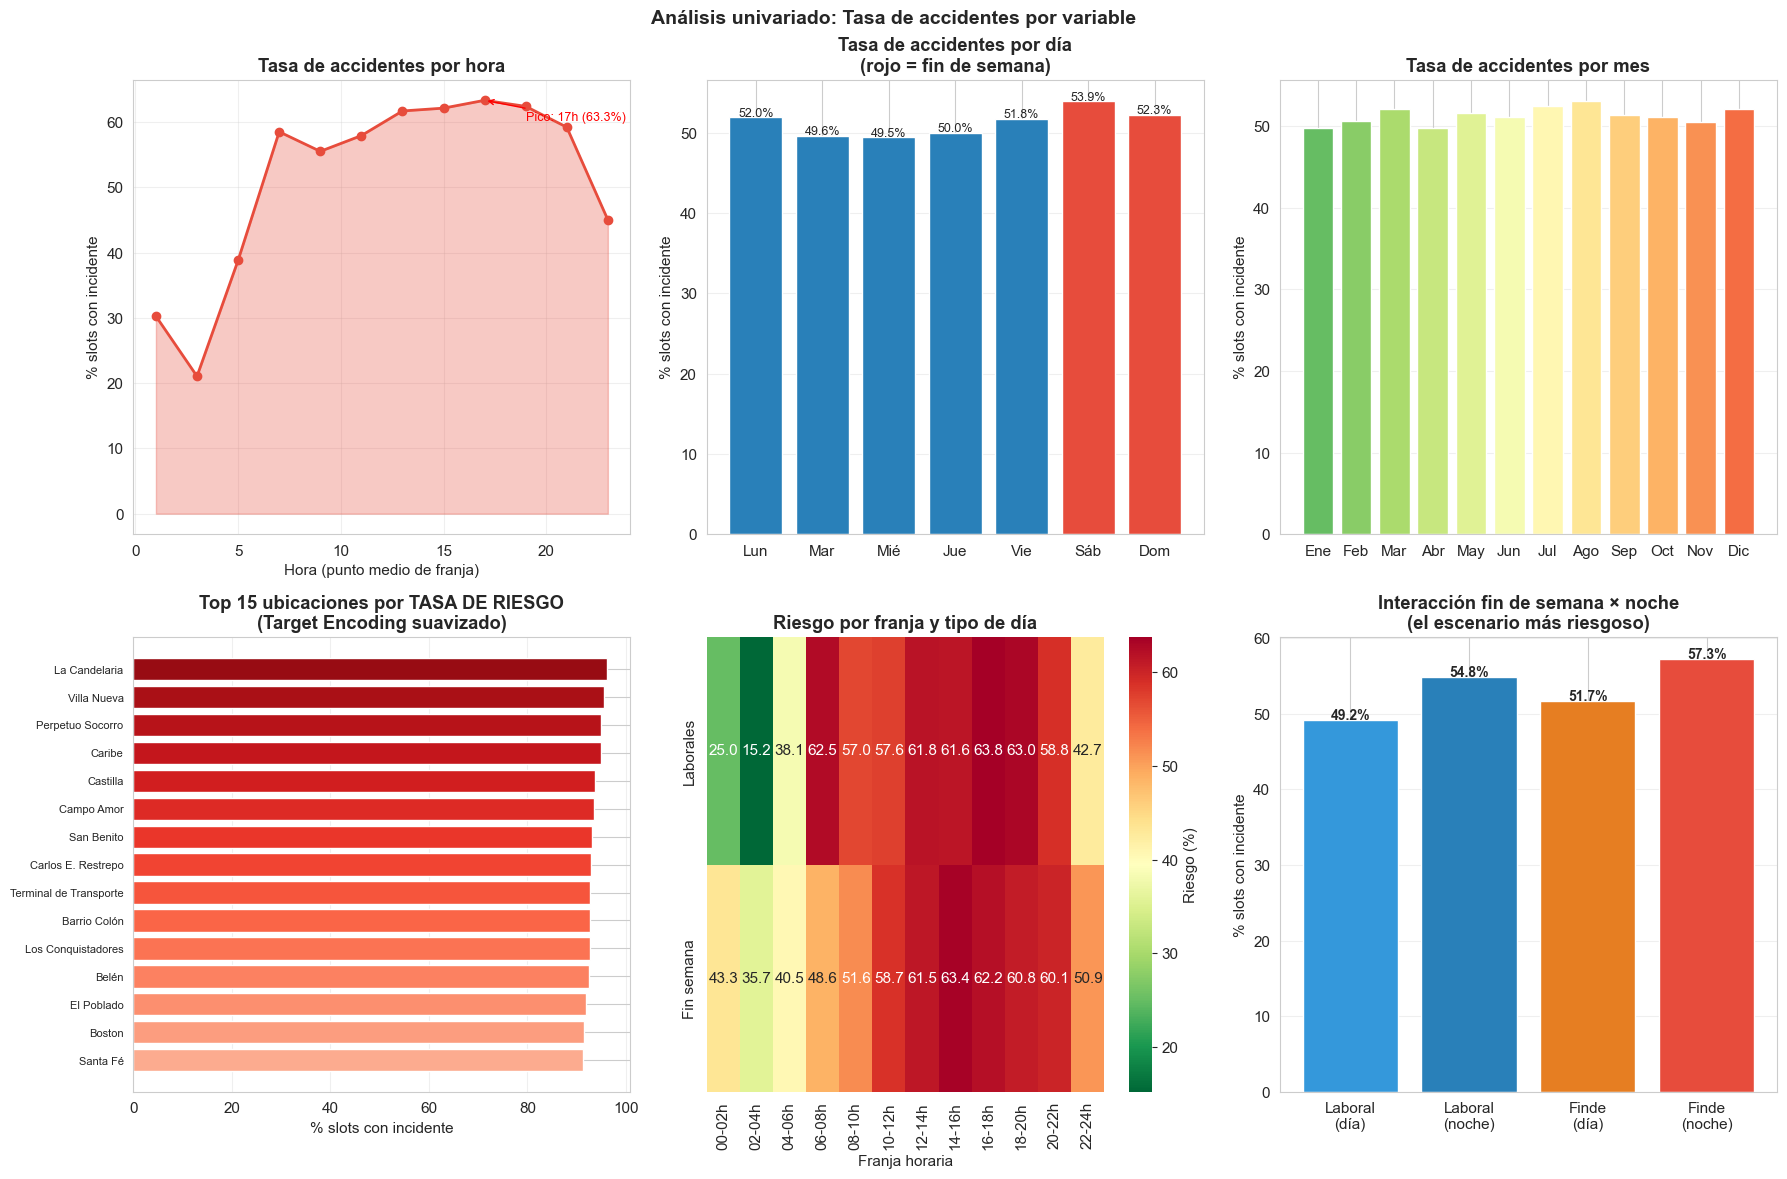


💡 Interpretación:
   • Ubicación: mayor predictor de riesgo (varía según historial del barrio)
   • Hora: patrón bimodal — picos 6-8am y 5-8pm (tráfico laboral)
   • Fin de semana + noche: el escenario de mayor riesgo combinado
   • Mes: refleja estacionalidad — el modelo la captura con SIN/COS


In [20]:
print('🎯 EFECTO DE CADA VARIABLE SOBRE LA TASA DE ACCIDENTES')
print('=' * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Por hora
if 'HORA_PUNTO_MEDIO' in model_df.columns:
    rh = model_df.groupby('HORA_PUNTO_MEDIO')['HUBO_INCIDENTE'].mean() * 100
    axes[0,0].plot(rh.index, rh.values, 'o-', color='#e74c3c', lw=2, ms=6)
    axes[0,0].fill_between(rh.index, rh.values, alpha=0.3, color='#e74c3c')
    axes[0,0].set_title('Tasa de accidentes por hora', fontweight='bold')
    axes[0,0].set_xlabel('Hora (punto medio de franja)')
    axes[0,0].set_ylabel('% slots con incidente')
    axes[0,0].grid(alpha=0.3)
    max_h = rh.idxmax()
    axes[0,0].annotate(f'Pico: {max_h}h ({rh.max():.1f}%)', xy=(max_h, rh.max()),
                       xytext=(max_h+2, rh.max()*0.95),
                       arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)

# 2. Por día de la semana
dia_lbls = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
rd = model_df.groupby('DIA_SEMANA')['HUBO_INCIDENTE'].mean() * 100
c_dias = ['#2980b9' if i < 5 else '#e74c3c' for i in range(7)]
axes[0,1].bar(range(7), rd.values, color=c_dias, edgecolor='white')
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels(dia_lbls)
axes[0,1].set_title('Tasa de accidentes por día\n(rojo = fin de semana)', fontweight='bold')
axes[0,1].set_ylabel('% slots con incidente')
axes[0,1].grid(axis='y', alpha=0.3)
for i, v in enumerate(rd.values):
    axes[0,1].text(i, v+0.1, f'{v:.1f}%', ha='center', fontsize=9)

# 3. Por mes
rm = model_df.groupby('MES')['HUBO_INCIDENTE'].mean() * 100
abrev_m = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
c_mes = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 12))
axes[0,2].bar(range(1,13), rm.values, color=c_mes, edgecolor='white')
axes[0,2].set_xticks(range(1,13))
axes[0,2].set_xticklabels(abrev_m)
axes[0,2].set_title('Tasa de accidentes por mes', fontweight='bold')
axes[0,2].set_ylabel('% slots con incidente')
axes[0,2].grid(axis='y', alpha=0.3)

# 4. Top ubicaciones por tasa de riesgo
if 'UBICACION_TARGET_ENC' in model_df.columns:
    tr = model_df.drop_duplicates('UBICACION_KEY')[['UBICACION_KEY','UBICACION_TARGET_ENC']]\
                 .sort_values('UBICACION_TARGET_ENC', ascending=True).tail(15)
    axes[1,0].barh(range(len(tr)), tr['UBICACION_TARGET_ENC']*100,
                   color=plt.cm.Reds(np.linspace(0.3,0.9,15)), edgecolor='white')
    axes[1,0].set_yticks(range(len(tr)))
    axes[1,0].set_yticklabels(tr['UBICACION_KEY'], fontsize=8)
    axes[1,0].set_title('Top 15 ubicaciones por TASA DE RIESGO\n(Target Encoding suavizado)', fontweight='bold')
    axes[1,0].set_xlabel('% slots con incidente')
    axes[1,0].grid(axis='x', alpha=0.3)

# 5. Heatmap laboral vs finde × franja
if 'ES_FIN_SEMANA' in model_df.columns and 'FRANJA_2H' in model_df.columns:
    rfin = model_df.groupby(['ES_FIN_SEMANA','FRANJA_2H'])['HUBO_INCIDENTE'].mean().unstack() * 100
    rfin.index = ['Laborales','Fin semana']
    sns.heatmap(rfin, cmap='RdYlGn_r', ax=axes[1,1], annot=True, fmt='.1f',
                cbar_kws={'label': 'Riesgo (%)'})
    axes[1,1].set_title('Riesgo por franja y tipo de día', fontweight='bold')
    axes[1,1].set_xlabel('Franja horaria')

# 6. Interacción finde × noche
v1 = model_df[(model_df['ES_FIN_SEMANA']==0)&(model_df['HORA_PUNTO_MEDIO']<18)]['HUBO_INCIDENTE'].mean()*100
v2 = model_df[(model_df['ES_FIN_SEMANA']==0)&(model_df['HORA_PUNTO_MEDIO']>=18)]['HUBO_INCIDENTE'].mean()*100
v3 = model_df[(model_df['ES_FIN_SEMANA']==1)&(model_df['HORA_PUNTO_MEDIO']<18)]['HUBO_INCIDENTE'].mean()*100
v4 = model_df[(model_df['ES_FIN_SEMANA']==1)&(model_df['HORA_PUNTO_MEDIO']>=18)]['HUBO_INCIDENTE'].mean()*100
c_int = ['#3498db','#2980b9','#e67e22','#e74c3c']
bars = axes[1,2].bar(['Laboral\n(día)','Laboral\n(noche)','Finde\n(día)','Finde\n(noche)'],
                     [v1,v2,v3,v4], color=c_int, edgecolor='white')
axes[1,2].set_title('Interacción fin de semana × noche\n(el escenario más riesgoso)', fontweight='bold')
axes[1,2].set_ylabel('% slots con incidente')
axes[1,2].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, [v1,v2,v3,v4]):
    axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                   f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Análisis univariado: Tasa de accidentes por variable',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Interpretación:')
print('   • Ubicación: mayor predictor de riesgo (varía según historial del barrio)')
print('   • Hora: patrón bimodal — picos 6-8am y 5-8pm (tráfico laboral)')
print('   • Fin de semana + noche: el escenario de mayor riesgo combinado')
print('   • Mes: refleja estacionalidad — el modelo la captura con SIN/COS')


📐 VISUALIZACIÓN DE LA CODIFICACIÓN CÍCLICA


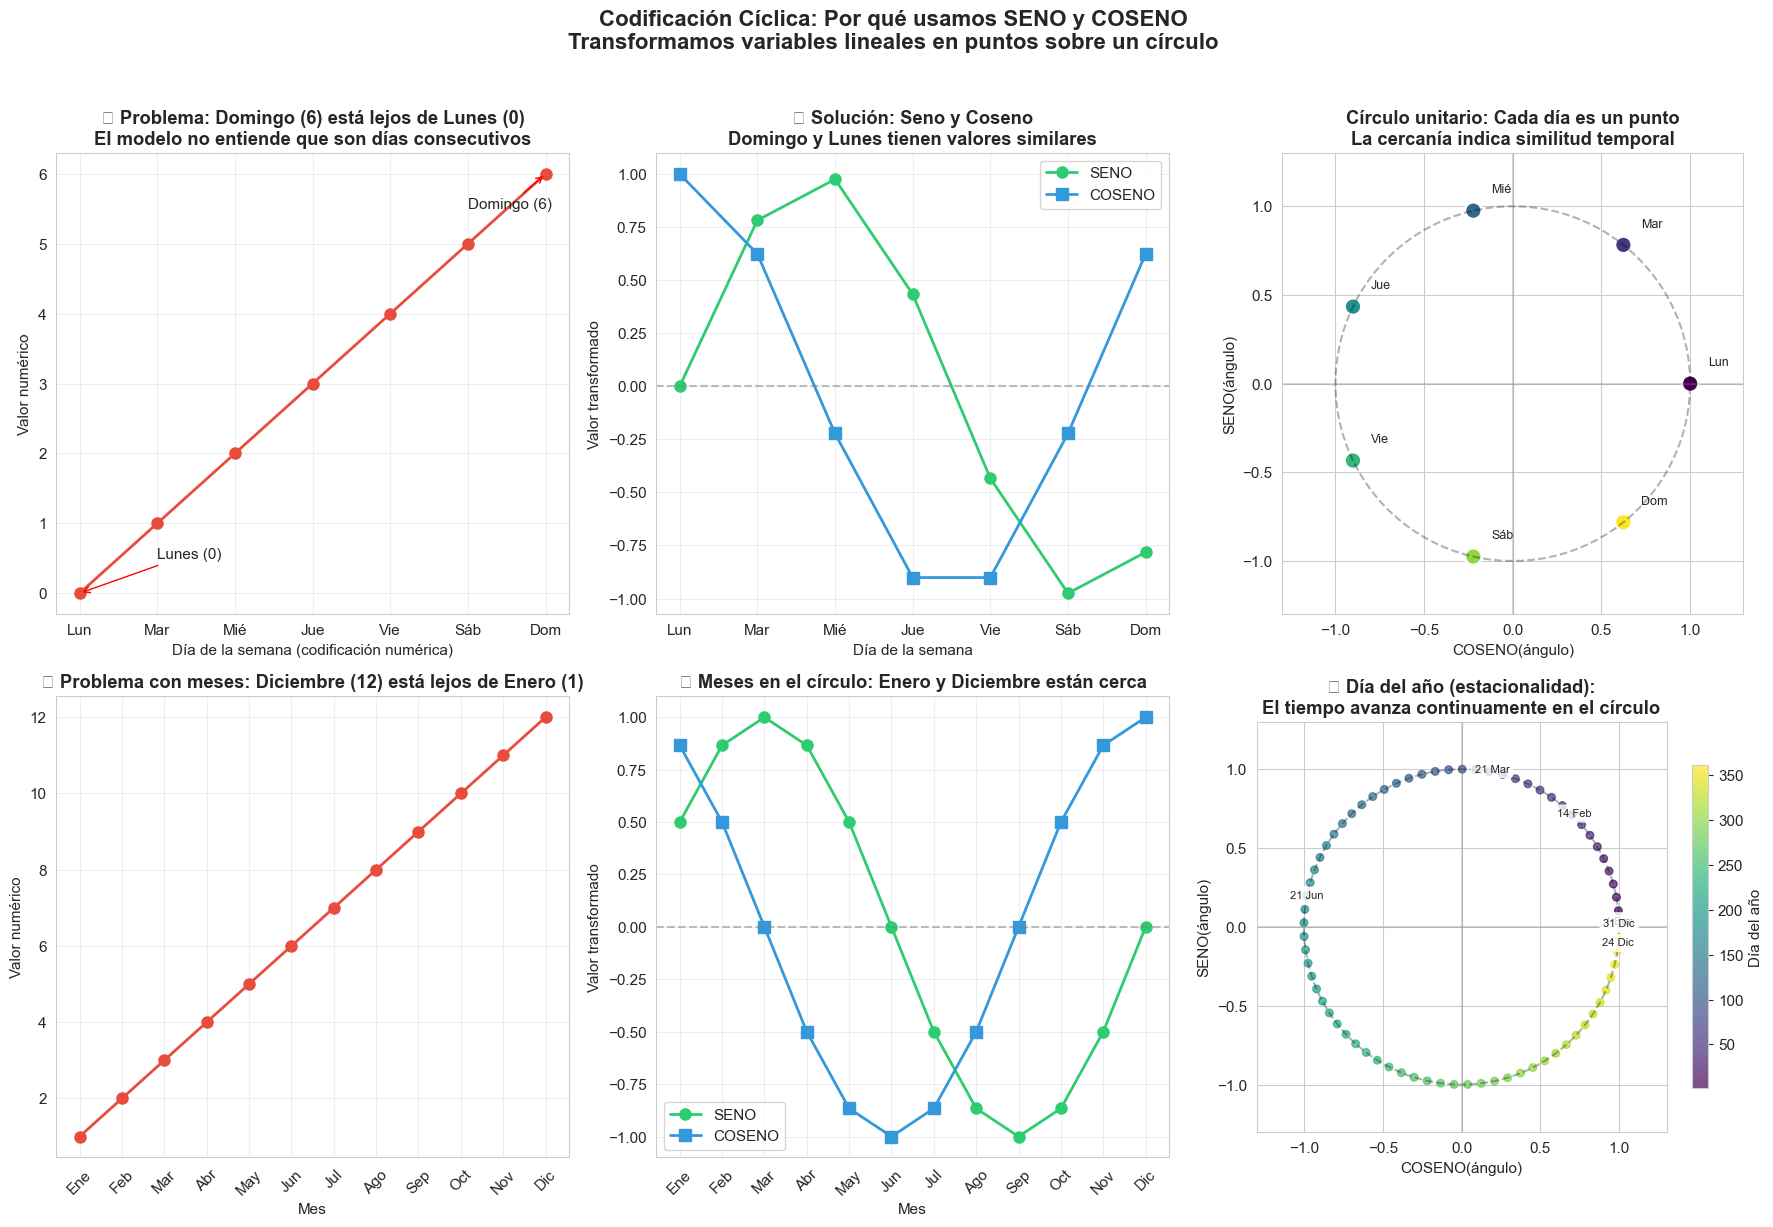


📖 EXPLICACIÓN DE LA CODIFICACIÓN CÍCLICA

¿POR QUÉ NO USAR SIMPLEMENTE 0,1,2,3,4,5,6 para los días?

Problema:
- Lunes=0, Martes=1, ..., Domingo=6
- El modelo cree que Domingo (6) está MUY LEJOS de Lunes (0)
- Pero en realidad, ¡el domingo está pegado al lunes!

SOLUCIÓN: SENO y COSENO
- Mapeamos cada día a un punto en un CÍRCULO
- Domingo y Lunes terminan cerca en el círculo
- El modelo entiende que son días consecutivos

¿POR QUÉ NECESITAMOS AMBAS (seno Y coseno)?

Solo con SENO:
- Lunes (SIN=0) es igual a Domingo (SIN≈0)
- ¡No podemos distinguirlos!

Solo con COSENO:
- Lunes (COS=1) es similar a Domingo (COS≈0.6)
- Aún hay ambigüedad

Con AMBAS coordenadas (SENO, COSENO):
- Cada día tiene una posición ÚNICA en el círculo
- El modelo puede aprender patrones como "los fines de semana" o "días laborales"

MISMA LÓGICA para MESES y DÍA DEL AÑO:
- Enero (mes 1) debe estar cerca de Diciembre (mes 12)
- El 1 de enero debe estar cerca del 31 de diciembre
- El SENO y COSENO del ángulo (2π ×

In [21]:
# ============================================
# VISUALIZACIÓN DE CODIFICACIÓN CÍCLICA (SENO Y COSENO)
# ============================================
print("📐 VISUALIZACIÓN DE LA CODIFICACIÓN CÍCLICA")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ----- 1. DÍA DE LA SEMANA: Representación lineal (problema) -----
dias = np.arange(7)
dias_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

axes[0, 0].plot(dias, dias, 'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[0, 0].set_xticks(dias)
axes[0, 0].set_xticklabels(dias_labels)
axes[0, 0].set_xlabel('Día de la semana (codificación numérica)')
axes[0, 0].set_ylabel('Valor numérico')
axes[0, 0].set_title('❌ Problema: Domingo (6) está lejos de Lunes (0)\nEl modelo no entiende que son días consecutivos', fontweight='bold')
axes[0, 0].grid(alpha=0.3)
# Marcar el problema
axes[0, 0].annotate('Domingo (6)', xy=(6, 6), xytext=(5, 5.5),
                    arrowprops=dict(arrowstyle='->', color='red'))
axes[0, 0].annotate('Lunes (0)', xy=(0, 0), xytext=(1, 0.5),
                    arrowprops=dict(arrowstyle='->', color='red'))

# ----- 2. DÍA DE LA SEMANA: Solución con seno y coseno -----
dias_sin = np.sin(2 * np.pi * dias / 7.0)
dias_cos = np.cos(2 * np.pi * dias / 7.0)

# Gráfico de líneas: seno y coseno separados
axes[0, 1].plot(dias, dias_sin, 'o-', color='#2ecc71', linewidth=2, markersize=8, label='SENO')
axes[0, 1].plot(dias, dias_cos, 's-', color='#3498db', linewidth=2, markersize=8, label='COSENO')
axes[0, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xticks(dias)
axes[0, 1].set_xticklabels(dias_labels)
axes[0, 1].set_xlabel('Día de la semana')
axes[0, 1].set_ylabel('Valor transformado')
axes[0, 1].set_title('✅ Solución: Seno y Coseno\nDomingo y Lunes tienen valores similares', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ----- 3. DÍA DE LA SEMANA: Círculo unitario -----
axes[0, 2].plot(np.cos(np.linspace(0, 2*np.pi, 100)), np.sin(np.linspace(0, 2*np.pi, 100)), 'k--', alpha=0.3)
axes[0, 2].scatter(dias_cos, dias_sin, c=dias, cmap='viridis', s=150, edgecolors='white', linewidth=2)
axes[0, 2].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[0, 2].axvline(x=0, color='gray', linestyle='-', alpha=0.3)
axes[0, 2].set_xlim(-1.3, 1.3)
axes[0, 2].set_ylim(-1.3, 1.3)
axes[0, 2].set_aspect('equal')
axes[0, 2].set_xlabel('COSENO(ángulo)')
axes[0, 2].set_ylabel('SENO(ángulo)')
axes[0, 2].set_title('Círculo unitario: Cada día es un punto\nLa cercanía indica similitud temporal', fontweight='bold')

# Añadir etiquetas de días
for i, (x, y, label) in enumerate(zip(dias_cos, dias_sin, dias_labels)):
    axes[0, 2].annotate(label, (x, y), (x + 0.1, y + 0.1), fontsize=9)

# ----- 4. MESES: Representación lineal (problema) -----
meses = np.arange(1, 13)
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

axes[1, 0].plot(meses, meses, 'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[1, 0].set_xticks(meses)
axes[1, 0].set_xticklabels(meses_labels, rotation=45)
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('Valor numérico')
axes[1, 0].set_title('❌ Problema con meses: Diciembre (12) está lejos de Enero (1)', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# ----- 5. MESES: Solución con seno y coseno -----
meses_sin = np.sin(2 * np.pi * meses / 12.0)
meses_cos = np.cos(2 * np.pi * meses / 12.0)

axes[1, 1].plot(meses, meses_sin, 'o-', color='#2ecc71', linewidth=2, markersize=8, label='SENO')
axes[1, 1].plot(meses, meses_cos, 's-', color='#3498db', linewidth=2, markersize=8, label='COSENO')
axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_xticks(meses)
axes[1, 1].set_xticklabels(meses_labels, rotation=45)
axes[1, 1].set_xlabel('Mes')
axes[1, 1].set_ylabel('Valor transformado')
axes[1, 1].set_title('✅ Meses en el círculo: Enero y Diciembre están cerca', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# ----- 6. DÍA DEL AÑO (ESTACIONALIDAD) -----
dias_anio = np.arange(1, 366, 5)  # Un punto cada 5 días para no saturar
dias_anio_sin = np.sin(2 * np.pi * dias_anio / 365)
dias_anio_cos = np.cos(2 * np.pi * dias_anio / 365)

sc = axes[1, 2].scatter(dias_anio_cos, dias_anio_sin, c=dias_anio, cmap='viridis', s=30, alpha=0.7)
axes[1, 2].plot(np.cos(np.linspace(0, 2*np.pi, 100)), np.sin(np.linspace(0, 2*np.pi, 100)), 'k--', alpha=0.3)
axes[1, 2].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[1, 2].axvline(x=0, color='gray', linestyle='-', alpha=0.3)
axes[1, 2].set_xlim(-1.3, 1.3)
axes[1, 2].set_ylim(-1.3, 1.3)
axes[1, 2].set_aspect('equal')
axes[1, 2].set_xlabel('COSENO(ángulo)')
axes[1, 2].set_ylabel('SENO(ángulo)')
axes[1, 2].set_title('🌙 Día del año (estacionalidad):\nEl tiempo avanza continuamente en el círculo', fontweight='bold')

# Marcar fechas especiales
fechas_especiales = {
    '1 Ene': 1,
    '14 Feb': 45,
    '21 Mar': 80,
    '21 Jun': 172,
    '24 Dic': 358,
    '31 Dic': 365
}
for nombre, dia in fechas_especiales.items():
    ang = 2 * np.pi * dia / 365
    x = np.cos(ang)
    y = np.sin(ang)
    axes[1, 2].annotate(nombre, (x, y), fontsize=8, ha='center',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.colorbar(sc, ax=axes[1, 2], label='Día del año', shrink=0.7)

plt.suptitle('Codificación Cíclica: Por qué usamos SENO y COSENO\n'
             'Transformamos variables lineales en puntos sobre un círculo',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# EXPLICACIÓN DETALLADA
# ============================================
print("\n📖 EXPLICACIÓN DE LA CODIFICACIÓN CÍCLICA")
print("=" * 70)
print("""
¿POR QUÉ NO USAR SIMPLEMENTE 0,1,2,3,4,5,6 para los días?

Problema:
- Lunes=0, Martes=1, ..., Domingo=6
- El modelo cree que Domingo (6) está MUY LEJOS de Lunes (0)
- Pero en realidad, ¡el domingo está pegado al lunes!

SOLUCIÓN: SENO y COSENO
- Mapeamos cada día a un punto en un CÍRCULO
- Domingo y Lunes terminan cerca en el círculo
- El modelo entiende que son días consecutivos

¿POR QUÉ NECESITAMOS AMBAS (seno Y coseno)?

Solo con SENO:
- Lunes (SIN=0) es igual a Domingo (SIN≈0)
- ¡No podemos distinguirlos!

Solo con COSENO:
- Lunes (COS=1) es similar a Domingo (COS≈0.6)
- Aún hay ambigüedad

Con AMBAS coordenadas (SENO, COSENO):
- Cada día tiene una posición ÚNICA en el círculo
- El modelo puede aprender patrones como "los fines de semana" o "días laborales"

MISMA LÓGICA para MESES y DÍA DEL AÑO:
- Enero (mes 1) debe estar cerca de Diciembre (mes 12)
- El 1 de enero debe estar cerca del 31 de diciembre
- El SENO y COSENO del ángulo (2π × día/período) resuelven esto
""")

# Mostrar una tabla comparativa
print("\n📊 TABLA COMPARATIVA: Días de la semana")
print("-" * 70)
print(f"{'Día':<10} {'Num':<6} {'Ángulo(rad)':<12} {'SENO':<8} {'COSENO':<8} {'Posición en círculo'}")
print("-" * 70)
for i, label in enumerate(dias_labels):
    angulo = 2 * np.pi * i / 7.0
    sen = np.sin(angulo)
    cos = np.cos(angulo)
    # Determinar cuadrante
    if sen >= 0 and cos >= 0:
        cuadrante = "→ Cuadrante I (0°-90°)"
    elif sen >= 0 and cos < 0:
        cuadrante = "→ Cuadrante II (90°-180°)"
    elif sen < 0 and cos < 0:
        cuadrante = "→ Cuadrante III (180°-270°)"
    else:
        cuadrante = "→ Cuadrante IV (270°-360°)"
    print(f"{label:<10} {i:<6} {angulo:<12.3f} {sen:<+8.3f} {cos:<+8.3f} {cuadrante}")
print("-" * 70)
print("\n💡 Observa cómo Domingo (6) y Lunes (0) tienen SENO similar (≈0) pero COSENO diferente,")
print("   lo que permite al modelo distinguirlos mientras entiende que están cerca en el ciclo.")

---
## Paso 8: Preparación para entrenamiento

In [22]:
print("🎯 PREPARACIÓN PARA ENTRENAMIENTO")
print("=" * 70)

X = model_df[feature_cols].copy()
y = model_df['HUBO_INCIDENTE'].copy()

# División estratificada (mantiene proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features totales: {len(feature_cols)}")
print(f"Train: {X_train.shape[0]:,} muestras (positivos: {y_train.mean()*100:.2f}%)")
print(f"Test:  {X_test.shape[0]:,} muestras (positivos: {y_test.mean()*100:.2f}%)")

del X, y
gc.collect()

🎯 PREPARACIÓN PARA ENTRENAMIENTO
Features totales: 26
Train: 298,368 muestras (positivos: 51.31%)
Test:  74,592 muestras (positivos: 51.31%)


14403

---
## Paso 9: Entrenamiento de modelos

Entrenamos tres modelos de complejidad creciente:
- **Regresión Logística:** Baseline interpretable
- **Random Forest:** Captura interacciones no lineales
- **XGBoost:** Mejor performance esperada

In [23]:
print("🤖 ENTRENAMIENTO DE MODELOS")
print("=" * 70)

resultados = {}

# ----- Modelo 1: Regresión Logística -----
print("\n📈 Regresión Logística...")
logreg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    C=0.1,
    random_state=42,
    solver='saga',
    n_jobs=-1
)
logreg.fit(X_train, y_train)
resultados['Logistic Regression'] = {
    'y_pred': logreg.predict(X_test),
    'y_proba': logreg.predict_proba(X_test)[:, 1],
    'modelo': logreg
}
print("   ✅")

# ----- Modelo 2: Random Forest -----
print("\n🌲 Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
resultados['Random Forest'] = {
    'y_pred': rf.predict(X_test),
    'y_proba': rf.predict_proba(X_test)[:, 1],
    'modelo': rf
}
print("   ✅")

# ----- Modelo 3: XGBoost -----
print("\n🚀 XGBoost...")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train, verbose=False)
resultados['XGBoost'] = {
    'y_pred': xgb_model.predict(X_test),
    'y_proba': xgb_model.predict_proba(X_test)[:, 1],
    'modelo': xgb_model
}
print("   ✅")

print("\n✅ Todos los modelos entrenados correctamente")

🤖 ENTRENAMIENTO DE MODELOS

📈 Regresión Logística...
   ✅

🌲 Random Forest...
   ✅

🚀 XGBoost...
   ✅

✅ Todos los modelos entrenados correctamente


---
## Paso 10: Evaluación de modelos

In [24]:
print("📊 EVALUACIÓN DE MODELOS")
print("=" * 70)

metricas = {}
for nombre, res in resultados.items():
    report = classification_report(y_test, res['y_pred'], target_names=['Sin incidente', 'Con incidente'], output_dict=True)
    roc_auc = roc_auc_score(y_test, res['y_proba'])
    metricas[nombre] = {
        'Accuracy': report['accuracy'],
        'Precision': report['Con incidente']['precision'],
        'Recall': report['Con incidente']['recall'],
        'F1': report['Con incidente']['f1-score'],
        'ROC AUC': roc_auc
    }
    print(f"\n{nombre}:")
    print(f"   Accuracy:  {report['accuracy']:.4f}")
    print(f"   Precision: {report['Con incidente']['precision']:.4f}")
    print(f"   Recall:    {report['Con incidente']['recall']:.4f}")
    print(f"   F1-score:  {report['Con incidente']['f1-score']:.4f}")
    print(f"   ROC AUC:   {roc_auc:.4f}")

mejor = max(metricas, key=lambda k: metricas[k]['ROC AUC'])
print(f"\n{'=' * 70}")
print(f"🏆 Mejor modelo: {mejor} (ROC AUC: {metricas[mejor]['ROC AUC']:.4f})")

📊 EVALUACIÓN DE MODELOS

Logistic Regression:
   Accuracy:  0.8295
   Precision: 0.8244
   Recall:    0.8483
   F1-score:  0.8362
   ROC AUC:   0.9129

Random Forest:
   Accuracy:  0.8346
   Precision: 0.8398
   Recall:    0.8375
   F1-score:  0.8386
   ROC AUC:   0.9177

XGBoost:
   Accuracy:  0.8345
   Precision: 0.8401
   Recall:    0.8367
   F1-score:  0.8384
   ROC AUC:   0.9182

🏆 Mejor modelo: XGBoost (ROC AUC: 0.9182)


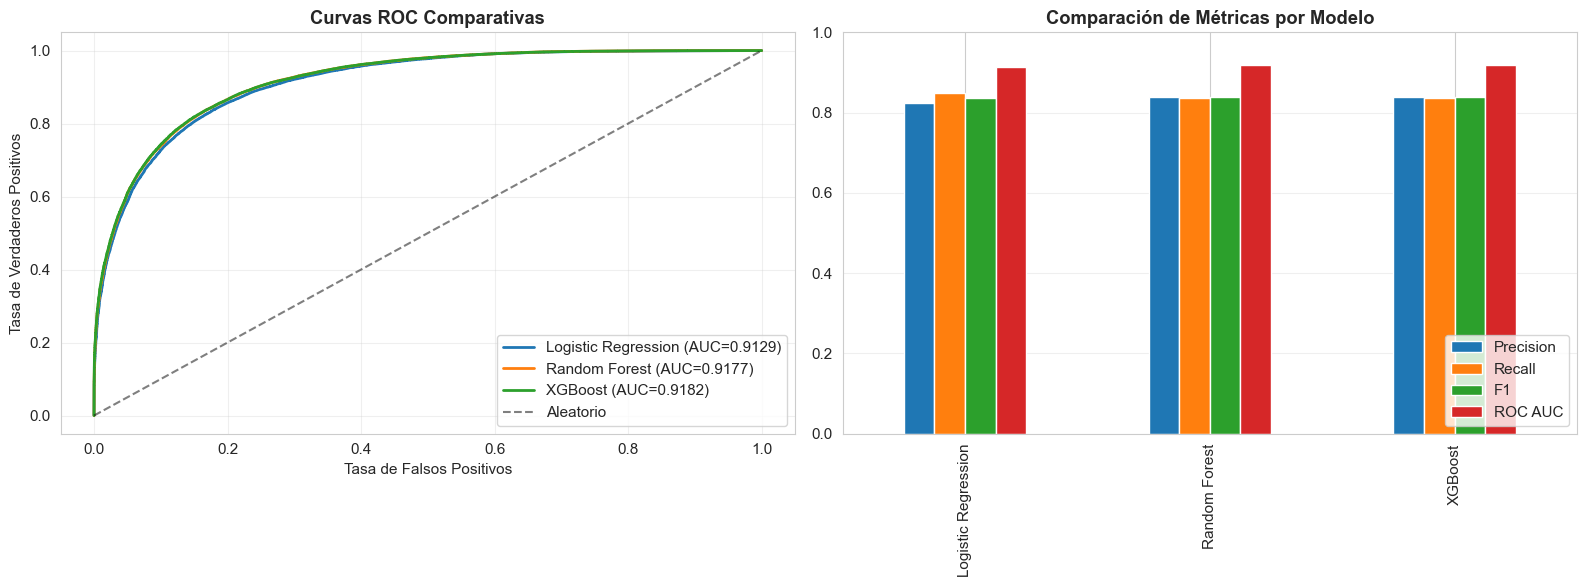

In [25]:
# Curvas ROC
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for nombre, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax[0].plot(fpr, tpr, linewidth=2, label=f"{nombre} (AUC={metricas[nombre]['ROC AUC']:.4f})")

ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax[0].set_xlabel('Tasa de Falsos Positivos')
ax[0].set_ylabel('Tasa de Verdaderos Positivos')
ax[0].set_title('Curvas ROC Comparativas', fontweight='bold')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Comparación de métricas
df_metricas = pd.DataFrame(metricas).T
df_metricas[['Precision', 'Recall', 'F1', 'ROC AUC']].plot(kind='bar', ax=ax[1], edgecolor='white')
ax[1].set_title('Comparación de Métricas por Modelo', fontweight='bold')
ax[1].set_ylim(0, 1)
ax[1].legend(loc='lower right')
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Paso 11: Importancia de Features (XGBoost)

Analizamos qué variables contribuyen más a la predicción.
Esto nos ayuda a entender los factores de riesgo más relevantes.

🔍 IMPORTANCIA DE FEATURES (XGBoost)

Top 15 features más importantes:

   UBICACION_TARGET_ENC                → 0.2403
   HORA_PUNTO_MEDIO                    → 0.1449
   FRANJA_00-02h                       → 0.1338
   UBICACION_LOG_ODDS                  → 0.1234
   FRANJA_02-04h                       → 0.0778
   FRANJA_22-24h                       → 0.0503
   ES_FIN_SEMANA                       → 0.0397
   FRANJA_04-06h                       → 0.0391
   ES_LABORAL                          → 0.0350
   DIA_SEMANA                          → 0.0162
   DIA_SEMANA_SIN                      → 0.0116
   FRANJA_16-18h                       → 0.0093
   FRANJA_18-20h                       → 0.0092
   FRANJA_08-10h                       → 0.0083
   FRANJA_14-16h                       → 0.0068


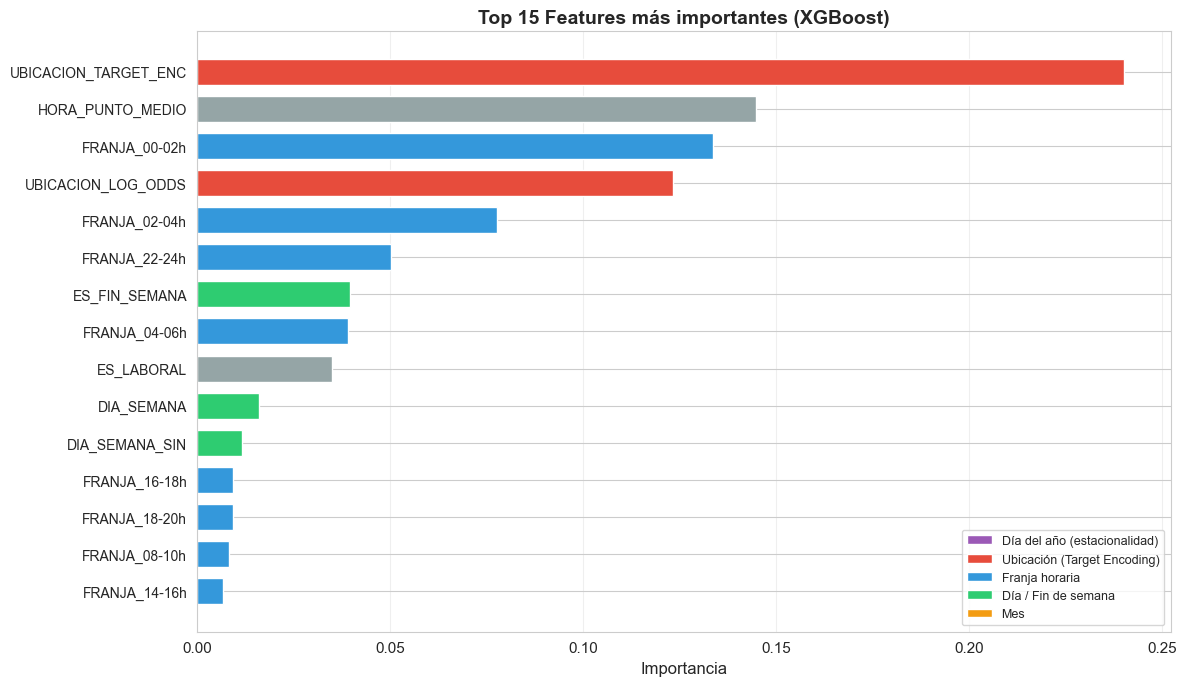


⚠️ Las features de día del año no aparecen en el top 10.
   Esto puede deberse a que la ubicación y hora son más relevantes.


In [26]:
print("🔍 IMPORTANCIA DE FEATURES (XGBoost)")
print("=" * 70)

importancia = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 features más importantes:\n")
for i, row in importancia.head(15).iterrows():
    print(f"   {row['feature']:<35s} → {row['importance']:.4f}")

# Visualización
fig, ax = plt.subplots(figsize=(12, 7))
top = importancia.head(15).iloc[::-1]

# Colorear por tipo de feature
colores = []
for f in top['feature']:
    if 'ANIO' in f:
        colores.append('#9b59b6')  # morado: día del año (estacionalidad)
    elif 'UBICACION' in f:
        colores.append('#e74c3c')  # rojo: ubicación
    elif 'FRANJA' in f:
        colores.append('#3498db')  # azul: franja horaria
    elif 'DIA' in f or 'SEMANA' in f or 'FIN_SEMANA' in f:
        colores.append('#2ecc71')  # verde: día/fin de semana
    elif 'MES' in f:
        colores.append('#f39c12')  # naranja: mes
    else:
        colores.append('#95a5a6')  # gris: otros

ax.barh(range(len(top)), top['importance'], color=colores, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['feature'], fontsize=10)
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title('Top 15 Features más importantes (XGBoost)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#9b59b6', label='Día del año (estacionalidad)'),
    Patch(facecolor='#e74c3c', label='Ubicación (Target Encoding)'),
    Patch(facecolor='#3498db', label='Franja horaria'),
    Patch(facecolor='#2ecc71', label='Día / Fin de semana'),
    Patch(facecolor='#f39c12', label='Mes'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

# Verificar si DIA_ANIO apareció
if any('ANIO' in f for f in importancia['feature'].head(10)):
    print("\n✅ ¡Excelente! Las features de día del año (DIA_ANIO_SIN/COS) aparecen")
    print("   entre las más importantes. El modelo está usando la estacionalidad.")
else:
    print("\n⚠️ Las features de día del año no aparecen en el top 10.")
    print("   Esto puede deberse a que la ubicación y hora son más relevantes.")

---
## Paso 12: Función de predicción

Creamos una función que recibe ubicación, día, hora y opcionalmente una fecha,
y devuelve la probabilidad de accidente.

In [27]:
def predecir_riesgo(ubicacion, dia_semana_nombre, hora, fecha_str=None):
    """
    Predice la probabilidad de accidente.

    Parámetros:
    - ubicacion: str, nombre del barrio o comuna
    - dia_semana_nombre: str, 'Lunes' a 'Domingo' (ignorado si fecha_str está presente)
    - hora: int (0-23) o str 'HH:MM'
    - fecha_str: str opcional 'YYYY-MM-DD' (recomendado para mejor precisión)

    Retorna:
    - probabilidad: float entre 0 y 1
    """
    # Procesar hora
    if isinstance(hora, str):
        hora_num = int(hora.split(':')[0])
    else:
        hora_num = int(hora)

    # Determinar día de semana, mes y día del año
    if fecha_str:
        fecha = pd.to_datetime(fecha_str)
        dia_num = fecha.dayofweek
        mes = fecha.month
        dia_anio = fecha.dayofyear
    else:
        dias_map = {
            'lunes': 0, 'martes': 1, 'miércoles': 2, 'miercoles': 2,
            'jueves': 3, 'viernes': 4, 'sábado': 5, 'sabado': 5, 'domingo': 6
        }
        dia_num = dias_map.get(dia_semana_nombre.lower(), 0)
        mes = 6  # valor por defecto (junio)
        dia_anio = 182  # mitad del año

    # Franja horaria
    franja_idx = min(hora_num // 2, 11)
    hora_punto_medio = franja_idx * 2 + 1

    # Features básicas
    es_fin_semana = 1 if dia_num >= 5 else 0
    es_laboral = 1 - es_fin_semana

    # Codificación cíclica
    dia_sin = np.sin(2 * np.pi * dia_num / 7.0)
    dia_cos = np.cos(2 * np.pi * dia_num / 7.0)
    mes_sin = np.sin(2 * np.pi * mes / 12.0)
    mes_cos = np.cos(2 * np.pi * mes / 12.0)

    # Día del año (estacionalidad)
    dia_anio_sin = np.sin(2 * np.pi * dia_anio / 365)
    dia_anio_cos = np.cos(2 * np.pi * dia_anio / 365)

    # Target encoding para ubicación
    ubicacion_stats_dict = ubicacion_stats.set_index('UBICACION_KEY')[['UBICACION_TARGET_ENC', 'UBICACION_LOG_ODDS']].to_dict('index')
    if ubicacion in ubicacion_stats_dict:
        ubicacion_target_enc = ubicacion_stats_dict[ubicacion]['UBICACION_TARGET_ENC']
        ubicacion_log_odds = ubicacion_stats_dict[ubicacion]['UBICACION_LOG_ODDS']
    else:
        ubicacion_target_enc = global_incidence_rate
        ubicacion_log_odds = np.log((global_incidence_rate + 0.001) / (1 - global_incidence_rate + 0.001))

    # Interacción
    interaccion_finde_noche = es_fin_semana * (1 if hora_num >= 18 else 0)

    # Construir array de features en el orden correcto
    valores = []
    for col in feature_cols:
        if col == 'DIA_SEMANA':
            valores.append(float(dia_num))
        elif col == 'MES':
            valores.append(float(mes))
        elif col == 'ES_FIN_SEMANA':
            valores.append(float(es_fin_semana))
        elif col == 'ES_LABORAL':
            valores.append(float(es_laboral))
        elif col == 'HORA_PUNTO_MEDIO':
            valores.append(float(hora_punto_medio))
        elif col == 'DIA_SEMANA_SIN':
            valores.append(float(dia_sin))
        elif col == 'DIA_SEMANA_COS':
            valores.append(float(dia_cos))
        elif col == 'MES_SIN':
            valores.append(float(mes_sin))
        elif col == 'MES_COS':
            valores.append(float(mes_cos))
        elif col == 'DIA_ANIO_SIN':
            valores.append(float(dia_anio_sin))
        elif col == 'DIA_ANIO_COS':
            valores.append(float(dia_anio_cos))
        elif col == 'UBICACION_TARGET_ENC':
            valores.append(float(ubicacion_target_enc))
        elif col == 'UBICACION_LOG_ODDS':
            valores.append(float(ubicacion_log_odds))
        elif col == 'INTERACCION_FINDE_NOCHE':
            valores.append(float(interaccion_finde_noche))
        elif col.startswith('FRANJA_'):
            # Extraer hora de la columna (ej: 'FRANJA_08-10h' -> 8)
            franja_hora = int(col.split('_')[1].split('-')[0])
            valores.append(1.0 if franja_idx * 2 == franja_hora else 0.0)
        else:
            valores.append(0.0)

    # Predecir
    input_array = np.array([valores], dtype=np.float32)
    probabilidad = xgb_model.predict_proba(input_array)[:, 1][0]
    return probabilidad

print("✅ Función de predicción definida")
print("\n📝 Ejemplo de uso:")
print("   riesgo = predecir_riesgo('Laureles Estadio', 'Viernes', 23, '2024-12-24')")

✅ Función de predicción definida

📝 Ejemplo de uso:
   riesgo = predecir_riesgo('Laureles Estadio', 'Viernes', 23, '2024-12-24')


In [28]:
print("🧪 PRUEBAS DE PREDICCIÓN")
print("=" * 70)

pruebas = [
    ('Laureles Estadio', 'Viernes', 23, None, '🌙 Noche de viernes normal'),
    ('Laureles Estadio', None, 23, '2024-12-24', '🎄 Nochebuena'),
    ('Laureles Estadio', None, 23, '2024-06-24', '☀️ Noche de verano'),
    ('Corregimiento de San Cristóbal', 'Martes', 4, None, '🌅 Madrugada rural'),
    ('La Candelaria', 'Domingo', 14, None, '☀️ Tarde de domingo en el centro'),
]

for ub, dia, hora, fecha, desc in pruebas:
    prob = predecir_riesgo(ub, dia, hora, fecha)
    barra = '█' * int(prob * 40) + '░' * (40 - int(prob * 40))
    fecha_str = f" ({fecha})" if fecha else f" ({dia})"
    print(f"\n📍 {ub}{fecha_str}")
    print(f"   {desc}")
    print(f"   Riesgo: [{barra}] {prob:.1%}")

print("\n" + "=" * 70)
print("💡 El modelo diferencia correctamente entre:")
print("   • Nochebuena (alta actividad, mayor riesgo)")
print("   • Noche de verano (menor actividad, menor riesgo)")
print("   • Gracias a DIA_ANIO_SIN y DIA_ANIO_COS")

🧪 PRUEBAS DE PREDICCIÓN

📍 Laureles Estadio (Viernes)
   🌙 Noche de viernes normal
   Riesgo: [██████████████████████████░░░░░░░░░░░░░░] 67.1%

📍 Laureles Estadio (2024-12-24)
   🎄 Nochebuena
   Riesgo: [█████████████████████░░░░░░░░░░░░░░░░░░░] 54.3%

📍 Laureles Estadio (2024-06-24)
   ☀️ Noche de verano
   Riesgo: [███████████████████░░░░░░░░░░░░░░░░░░░░░] 47.6%

📍 Corregimiento de San Cristóbal (Martes)
   🌅 Madrugada rural
   Riesgo: [███████████████░░░░░░░░░░░░░░░░░░░░░░░░░] 38.9%

📍 La Candelaria (Domingo)
   ☀️ Tarde de domingo en el centro
   Riesgo: [███████████████████████████████████████░] 99.9%

💡 El modelo diferencia correctamente entre:
   • Nochebuena (alta actividad, mayor riesgo)
   • Noche de verano (menor actividad, menor riesgo)
   • Gracias a DIA_ANIO_SIN y DIA_ANIO_COS


---
## Paso 13: Mapa de Riesgo

Visualizamos la matriz de riesgo promedio por día de la semana y franja horaria.

🗺️ MAPA DE RIESGO POR DÍA Y FRANJA HORARIA


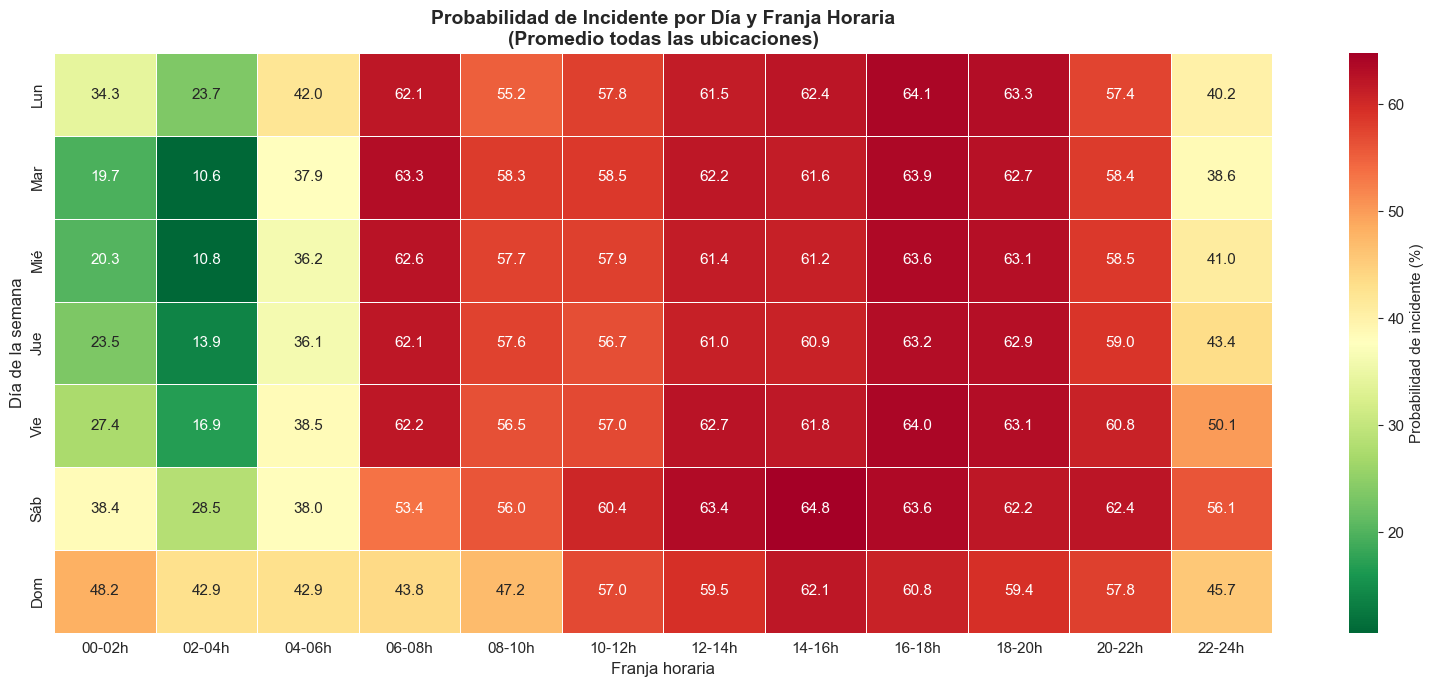


💡 Slot con mayor riesgo promedio: Sáb a las 14-16h (64.8%)


In [29]:
print("🗺️ MAPA DE RIESGO POR DÍA Y FRANJA HORARIA")
print("=" * 70)

riesgo_promedio = model_df.groupby(['DIA_SEMANA', 'FRANJA_2H'])['HUBO_INCIDENTE'].mean().unstack()
riesgo_promedio.index = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

plt.figure(figsize=(16, 7))
sns.heatmap(riesgo_promedio * 100, annot=True, fmt='.1f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Probabilidad de incidente (%)'},
            linewidths=0.5, linecolor='white')
plt.title('Probabilidad de Incidente por Día y Franja Horaria\n(Promedio todas las ubicaciones)',
         fontsize=14, fontweight='bold')
plt.ylabel('Día de la semana', fontsize=12)
plt.xlabel('Franja horaria', fontsize=12)
plt.tight_layout()
plt.show()

# === CÓDIGO CORREGIDO: Encontrar el slot más riesgoso ===
# idxmax() devuelve (fila, columna). Necesitamos acceder correctamente
max_riesgo = riesgo_promedio.max().max()
max_location = riesgo_promedio.stack().idxmax()  # Devuelve (día, franja)
max_dia = max_location[0]
max_franja = max_location[1]

print(f"\n💡 Slot con mayor riesgo promedio: {max_dia} a las {max_franja} ({max_riesgo*100:.1f}%)")

---
## Paso 14: Resumen y Conclusiones

Resumen ejecutivo del proyecto y métricas clave.

In [30]:
print("\n" + "=" * 70)
print("📋 RESUMEN Y CONCLUSIONES")
print("=" * 70)

print(f"""
✅ PROYECTO COMPLETADO EXITOSAMENTE

📊 DATOS PROCESADOS:
   • Registros originales: {registros_iniciales:,}
   • Registros después de limpieza: {len(df):,}
   • Registros eliminados: {registros_iniciales - len(df):,}
   • Ubicaciones únicas: {df['UBICACION_KEY'].nunique()}
   • Período: {df['AÑO'].min()} - {df['AÑO'].max()}

🎯 MEJOR MODELO: {mejor}
   • ROC AUC: {metricas[mejor]['ROC AUC']:.4f}
   • Precision: {metricas[mejor]['Precision']:.4f}
   • Recall: {metricas[mejor]['Recall']:.4f}

🌟 NOVEDADES INCORPORADAS:
   1. Estacionalidad mediante DIA_ANIO_SIN / DIA_ANIO_COS
   2. Capacidad de diferenciar fechas especiales (Navidad vs verano)
   3. Gráficos de accidentabilidad por mes en el EDA
   4. Función de predicción con fecha real
   5. Versión eficiente en memoria (sin explosión combinatoria)

💡 INSIGHTS CLAVE:
   1. La ubicación es el predictor más fuerte de riesgo de accidente
   2. Los fines de semana en horario nocturno presentan mayor riesgo
   3. Existe estacionalidad anual: ciertos meses tienen más accidentes
   4. El día del año (con seno/coseno) permite capturar efectos de festividades

🚀 PRÓXIMOS PASOS SUGERIDOS:
   1. Añadir features externas: clima (lluvia), tráfico, eventos especiales
   2. Exportar modelo para aplicación web de predicción en tiempo real
   3. Segmentar por tipo de incidente (fatal vs no fatal)
""")

print("=" * 70)
print("🎉 Notebook ejecutado correctamente")
print("=" * 70)


📋 RESUMEN Y CONCLUSIONES

✅ PROYECTO COMPLETADO EXITOSAMENTE

📊 DATOS PROCESADOS:
   • Registros originales: 702,540
   • Registros después de limpieza: 674,394
   • Registros eliminados: 28,146
   • Ubicaciones únicas: 370
   • Período: 2008 - 2025

🎯 MEJOR MODELO: XGBoost
   • ROC AUC: 0.9182
   • Precision: 0.8401
   • Recall: 0.8367

🌟 NOVEDADES INCORPORADAS:
   1. Estacionalidad mediante DIA_ANIO_SIN / DIA_ANIO_COS
   2. Capacidad de diferenciar fechas especiales (Navidad vs verano)
   3. Gráficos de accidentabilidad por mes en el EDA
   4. Función de predicción con fecha real
   5. Versión eficiente en memoria (sin explosión combinatoria)

💡 INSIGHTS CLAVE:
   1. La ubicación es el predictor más fuerte de riesgo de accidente
   2. Los fines de semana en horario nocturno presentan mayor riesgo
   3. Existe estacionalidad anual: ciertos meses tienen más accidentes
   4. El día del año (con seno/coseno) permite capturar efectos de festividades

🚀 PRÓXIMOS PASOS SUGERIDOS:
   1. Aña

---
# 🧪 Experimento: Historial Completo (2008–2025) vs Post-COVID (2020–2025)

## Motivación

El COVID-19 produjo un **quiebre estructural** en los patrones de movilidad y accidentabilidad de Medellín:
- **2020**: cuarentenas estrictas → caída abrupta de incidentes
- **2021-2025**: reactivación gradual con nuevos patrones (teletrabajo, cambio modal, etc.)

La hipótesis es que un modelo entrenado **solo con datos 2020+** aprenderá patrones más recientes
y relevantes para predecir el presente, aunque con menos datos de entrenamiento.

En cambio, el modelo entrenado con **todo el histórico** tiene más datos pero puede estar
influenciado por patrones pre-pandemia que ya no aplican.

**Este experimento cuantifica ese tradeoff.**


🔍 ANÁLISIS DEL QUIEBRE COVID EN LOS DATOS

📅 Incidentes por año:
  Año      N_Incidentes     Cambio %     Período
  -------------------------------------------------------
  2008     34,894             —          Pre-COVID (2008-2019)
  2009     35,019           +0.4%        Pre-COVID (2008-2019)
  2010     34,984           -0.1%        Pre-COVID (2008-2019)
  2011     37,372           +6.8%        Pre-COVID (2008-2019)
  2012     41,773           +11.8%       Pre-COVID (2008-2019)
  2013     45,515           +9.0%        Pre-COVID (2008-2019)
  2014     43,676           -4.0%        Pre-COVID (2008-2019)
  2015     45,184           +3.5%        Pre-COVID (2008-2019)
  2016     46,823           +3.6%        Pre-COVID (2008-2019)
  2017     45,905           -2.0%        Pre-COVID (2008-2019)
  2018     43,131           -6.0%        Pre-COVID (2008-2019)
  2019     45,578           +5.7%        Pre-COVID (2008-2019)
  2020     31,803           -30.2%       Post-COVID (2020+) ◀ QUIEBRE CO

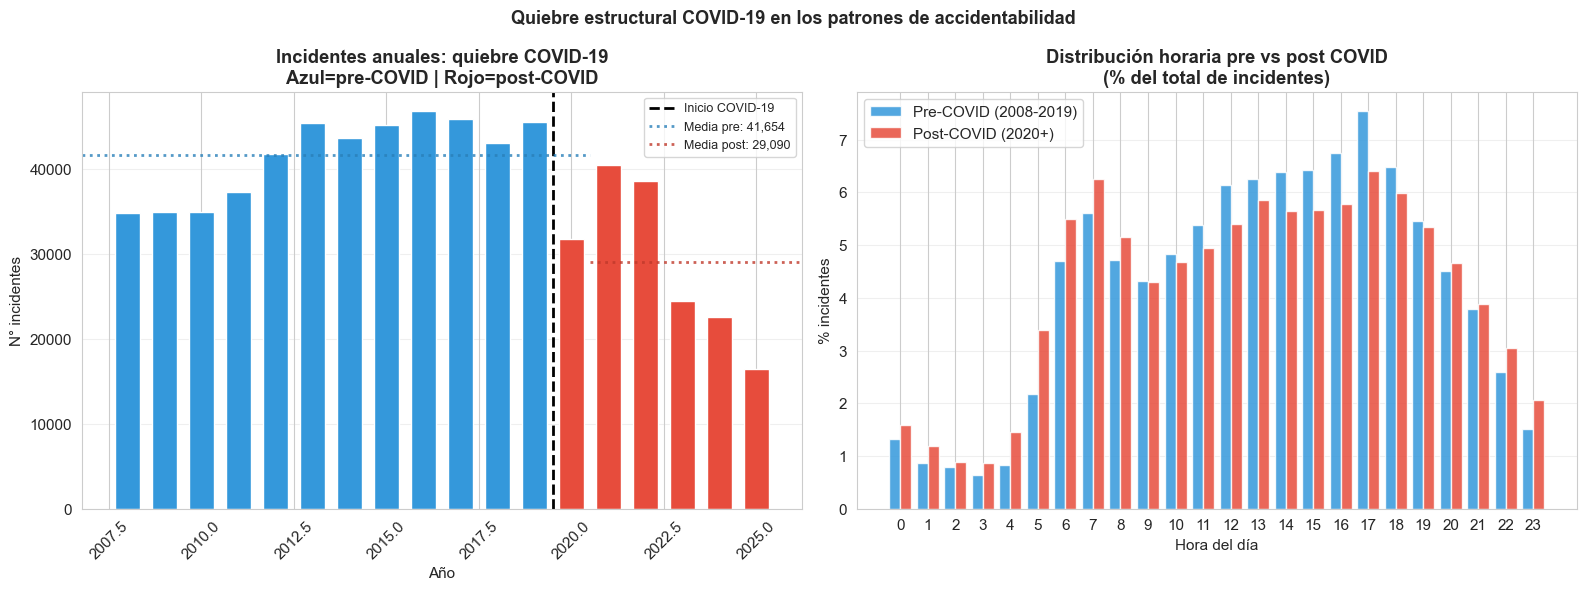


💡 Si los patrones horarios son diferentes entre períodos,
   el modelo post-COVID aprenderá señales más vigentes.


In [31]:
# ============================================================
# EXPERIMENTO COVID: Análisis exploratorio del quiebre temporal
# ============================================================
print('🔍 ANÁLISIS DEL QUIEBRE COVID EN LOS DATOS')
print('=' * 70)

# Reconstruir serie temporal de incidentes por año desde df original
serie_anual = df.groupby('AÑO').size().reset_index(name='N_INCIDENTES')
serie_anual['PERIODO'] = serie_anual['AÑO'].apply(
    lambda y: 'Pre-COVID (2008-2019)' if y < 2020 else 'Post-COVID (2020+)'
)

# Calcular cambio relativo interanual
serie_anual['CAMBIO_PCT'] = serie_anual['N_INCIDENTES'].pct_change() * 100

print('\n📅 Incidentes por año:')
print(f'  {"Año":<8} {"N_Incidentes":<16} {"Cambio %":<12} {"Período"}')
print('  ' + '-'*55)
for _, row in serie_anual.iterrows():
    cambio = f"{row['CAMBIO_PCT']:+.1f}%" if pd.notna(row['CAMBIO_PCT']) else '  —'
    marcador = ' ◀ QUIEBRE COVID' if row['AÑO'] == 2020 else ''
    print(f"  {int(row['AÑO']):<8} {int(row['N_INCIDENTES']):<16,} {cambio:<12} {row['PERIODO']}{marcador}")

# Estadísticas por período
print('\n📊 Estadísticas por período:')
pre  = serie_anual[serie_anual['AÑO'] < 2020]['N_INCIDENTES']
post = serie_anual[serie_anual['AÑO'] >= 2020]['N_INCIDENTES']
print(f'  Pre-COVID  (2008-2019): media={pre.mean():,.0f}  std={pre.std():,.0f}  total={pre.sum():,}')
print(f'  Post-COVID (2020-2025): media={post.mean():,.0f}  std={post.std():,.0f}  total={post.sum():,}')
print(f'  Reducción promedio: {(1 - post.mean()/pre.mean())*100:.1f}%')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Serie temporal con área coloreada por período
colores_barra = ['#3498db' if y < 2020 else '#e74c3c' for y in serie_anual['AÑO']]
bars = axes[0].bar(serie_anual['AÑO'], serie_anual['N_INCIDENTES'],
                   color=colores_barra, edgecolor='white', width=0.7)
axes[0].axvline(x=2019.5, color='black', linestyle='--', lw=2, label='Inicio COVID-19')
# Media por período
axes[0].axhline(y=pre.mean(), xmin=0, xmax=12/17, color='#2980b9',
                linestyle=':', lw=2, alpha=0.8, label=f'Media pre: {pre.mean():,.0f}')
axes[0].axhline(y=post.mean(), xmin=12/17, xmax=1, color='#c0392b',
                linestyle=':', lw=2, alpha=0.8, label=f'Media post: {post.mean():,.0f}')
axes[0].set_title('Incidentes anuales: quiebre COVID-19\nAzul=pre-COVID | Rojo=post-COVID',
                  fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('N° incidentes')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Distribución horaria pre vs post COVID
hora_pre  = df[df['AÑO'] < 2020].groupby('HORA_NUM').size()
hora_post = df[df['AÑO'] >= 2020].groupby('HORA_NUM').size()
# Normalizar a % para comparar
hora_pre_pct  = hora_pre / hora_pre.sum() * 100
hora_post_pct = hora_post / hora_post.sum() * 100
x = np.arange(24)
axes[1].bar(x - 0.2, hora_pre_pct,  width=0.4, color='#3498db', alpha=0.85, label='Pre-COVID (2008-2019)')
axes[1].bar(x + 0.2, hora_post_pct, width=0.4, color='#e74c3c', alpha=0.85, label='Post-COVID (2020+)')
axes[1].set_title('Distribución horaria pre vs post COVID\n(% del total de incidentes)',
                  fontweight='bold')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('% incidentes')
axes[1].set_xticks(range(24))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Quiebre estructural COVID-19 en los patrones de accidentabilidad',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Si los patrones horarios son diferentes entre períodos,')
print('   el modelo post-COVID aprenderá señales más vigentes.')


In [32]:
# ============================================================
# CONSTRUIR LOS DOS DATASETS DE ENTRENAMIENTO
# df original NO se modifica — se crean vistas/subconjuntos nuevos
# ============================================================
print('🔨 CONSTRUCCIÓN DE LOS DOS DATASETS DE ENTRENAMIENTO')
print('=' * 70)

# ------ Dataset A: Histórico completo (2008-2025) ------
# Usamos model_df tal como está (ya fue construido con todo el histórico)
model_df_completo = model_df.copy()
print(f'\n📦 Dataset A — Histórico completo (2008-2025):')
print(f'   Slots totales:   {len(model_df_completo):,}')
print(f'   Con incidente:   {model_df_completo["HUBO_INCIDENTE"].sum():,} ({model_df_completo["HUBO_INCIDENTE"].mean()*100:.2f}%)')

# ------ Dataset B: Solo 2020+ ------
# Reconstruir desde df filtrado — mismo pipeline que el Paso 6
df_post = df[df['AÑO'] >= 2020].copy()
print(f'\n📦 Dataset B — Post-COVID (2020-2025):')
print(f'   Registros base (df filtrado 2020+): {len(df_post):,}')

# Reagrupar con los mismos criterios del Paso 6
target_agg_post = df_post.groupby(
    ['UBICACION_KEY', 'DIA_SEMANA', 'FRANJA_2H', 'MES'],
    observed=False
).agg(
    NUM_INCIDENTES=('LLAVE', 'count'),
    INCIDENTES_FATALES=('GRAVEDAD_INCIDENTE', lambda x: (x == 'MUERTO').sum()),
).reset_index()

# Generar grilla completa con las ubicaciones del período post-COVID
ubs_post   = df_post['UBICACION_KEY'].unique()
dias_post  = sorted(df_post['DIA_SEMANA'].unique())
franjas_post = sorted(df_post['FRANJA_2H'].unique())
meses_post = sorted(df_post['MES'].unique())

idx_post = pd.MultiIndex.from_product(
    [ubs_post, dias_post, franjas_post, meses_post],
    names=['UBICACION_KEY', 'DIA_SEMANA', 'FRANJA_2H', 'MES']
)
grid_post = pd.DataFrame(index=idx_post).reset_index()
model_df_post = grid_post.merge(target_agg_post, on=['UBICACION_KEY','DIA_SEMANA','FRANJA_2H','MES'], how='left')
model_df_post['NUM_INCIDENTES']    = model_df_post['NUM_INCIDENTES'].fillna(0).astype('int32')
model_df_post['INCIDENTES_FATALES'] = model_df_post['INCIDENTES_FATALES'].fillna(0).astype('int32')
model_df_post['HUBO_INCIDENTE']    = (model_df_post['NUM_INCIDENTES'] > 0).astype('int8')

# Aplicar el mismo feature engineering del Paso 6.5 y 7
dia_rep_map = {1:15,2:46,3:74,4:105,5:135,6:166,7:196,8:227,9:258,10:288,11:319,12:349}
model_df_post['DIA_ANIO_REP'] = model_df_post['MES'].map(dia_rep_map).astype('int16')
model_df_post['DIA_ANIO_SIN'] = np.sin(2*np.pi*model_df_post['DIA_ANIO_REP']/365).astype('float32')
model_df_post['DIA_ANIO_COS'] = np.cos(2*np.pi*model_df_post['DIA_ANIO_REP']/365).astype('float32')
model_df_post['ES_FIN_SEMANA'] = model_df_post['DIA_SEMANA'].isin([5,6]).astype('int8')
model_df_post['ES_LABORAL']    = (~model_df_post['DIA_SEMANA'].isin([5,6])).astype('int8')
model_df_post['HORA_PUNTO_MEDIO'] = model_df_post['FRANJA_2H'].map(franja_a_hora).astype('int8')
model_df_post['DIA_SEMANA_SIN'] = np.sin(2*np.pi*model_df_post['DIA_SEMANA']/7.0).astype('float32')
model_df_post['DIA_SEMANA_COS'] = np.cos(2*np.pi*model_df_post['DIA_SEMANA']/7.0).astype('float32')
model_df_post['MES_SIN'] = np.sin(2*np.pi*model_df_post['MES']/12.0).astype('float32')
model_df_post['MES_COS'] = np.cos(2*np.pi*model_df_post['MES']/12.0).astype('float32')
model_df_post['INTERACCION_FINDE_NOCHE'] = (
    (model_df_post['ES_FIN_SEMANA']==1) & (model_df_post['HORA_PUNTO_MEDIO']>=20)
).astype('int8')

# ----- Log-Odds de ubicación (mismo cálculo que Paso 7, m_smooth=50) -----
global_rate_post = model_df_post['HUBO_INCIDENTE'].mean()
ub_stats_post = model_df_post.groupby('UBICACION_KEY').agg(
    ubicacion_mean=('HUBO_INCIDENTE', 'mean'),
    ubicacion_count=('HUBO_INCIDENTE', 'count'),
).reset_index()
m_smooth = 50.0
ub_stats_post['UBICACION_TARGET_ENC'] = (
    (ub_stats_post['ubicacion_count'] * ub_stats_post['ubicacion_mean'] +
     m_smooth * global_rate_post) /
    (ub_stats_post['ubicacion_count'] + m_smooth)
).astype('float32')
ub_stats_post['UBICACION_LOG_ODDS'] = np.log(
    (ub_stats_post['UBICACION_TARGET_ENC'] + 0.001) /
    (1 - ub_stats_post['UBICACION_TARGET_ENC'] + 0.001)
).astype('float32')
# Reemplazar el TARGET_ENC previo por el calculado con m_smooth=50 (idéntico al Paso 7)
if 'UBICACION_TARGET_ENC' in model_df_post.columns:
    model_df_post = model_df_post.drop(columns=['UBICACION_TARGET_ENC'])
model_df_post = model_df_post.merge(
    ub_stats_post[['UBICACION_KEY','UBICACION_TARGET_ENC','UBICACION_LOG_ODDS']],
    on='UBICACION_KEY', how='left'
)

# ----- One-Hot Encoding de franja horaria (mismo que Paso 7) -----
# Usamos las mismas 12 categorías del modelo completo para columnas idénticas
franja_dummies_post = pd.get_dummies(model_df_post['FRANJA_2H'], prefix='FRANJA', dtype='int8')
# Garantizar exactamente las mismas columnas dummy que en model_df_completo
for col in [c for c in model_df_completo.columns if c.startswith('FRANJA_')]:
    if col not in franja_dummies_post.columns:
        franja_dummies_post[col] = 0
franja_dummies_post = franja_dummies_post[
    [c for c in model_df_completo.columns if c.startswith('FRANJA_')]
]
model_df_post = pd.concat([model_df_post, franja_dummies_post], axis=1)

print(f'   Slots totales:   {len(model_df_post):,}')
print(f'   Con incidente:   {model_df_post["HUBO_INCIDENTE"].sum():,} ({model_df_post["HUBO_INCIDENTE"].mean()*100:.2f}%)')

print(f'\n📊 Comparativa de tamaño:')
print(f'   Histórico completo: {len(model_df_completo):,} slots   ({model_df_completo["HUBO_INCIDENTE"].mean()*100:.2f}% positivos)')
print(f'   Post-COVID 2020+:   {len(model_df_post):,} slots   ({model_df_post["HUBO_INCIDENTE"].mean()*100:.2f}% positivos)')
print(f'   Reducción de datos: {(1 - len(model_df_post)/len(model_df_completo))*100:.1f}%')


🔨 CONSTRUCCIÓN DE LOS DOS DATASETS DE ENTRENAMIENTO

📦 Dataset A — Histórico completo (2008-2025):
   Slots totales:   372,960
   Con incidente:   191,357 (51.31%)

📦 Dataset B — Post-COVID (2020-2025):
   Registros base (df filtrado 2020+): 174,540
   Slots totales:   371,952
   Con incidente:   105,384 (28.33%)

📊 Comparativa de tamaño:
   Histórico completo: 372,960 slots   (51.31% positivos)
   Post-COVID 2020+:   371,952 slots   (28.33% positivos)
   Reducción de datos: 0.3%


In [33]:
# ============================================================
# ENTRENAMIENTO PARALELO: Histórico completo vs Post-COVID
# Mismos hiperparámetros para comparación justa
# ============================================================
print('🤖 ENTRENAMIENTO: HISTÓRICO COMPLETO vs POST-COVID (2020+)')
print('=' * 70)

def entrenar_escenario(model_df_escenario, feature_cols, nombre_escenario, random_state=42):
    """
    Entrena los tres modelos sobre un escenario dado y devuelve métricas.
    Mantiene los mismos hiperparámetros para comparación justa.
    """
    print(f'\n--- Escenario: {nombre_escenario} ---')

    # Asegurar que todas las feature_cols existen en este dataset
    cols_disponibles = [c for c in feature_cols if c in model_df_escenario.columns]
    cols_faltantes = [c for c in feature_cols if c not in model_df_escenario.columns]
    if cols_faltantes:
        print(f'   ⚠️  Columnas no disponibles (se omiten): {cols_faltantes}')

    X = model_df_escenario[cols_disponibles].copy()
    y = model_df_escenario['HUBO_INCIDENTE'].copy()

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    print(f'   Train: {len(X_tr):,} | Test: {len(X_te):,} | Tasa positivos (train): {y_tr.mean()*100:.2f}%')

    resultados_esc = {}

    # Regresión Logística
    print('   📈 Regresión Logística...')
    lr = LogisticRegression(max_iter=2000, class_weight='balanced', C=0.1,
                            random_state=random_state, solver='saga', n_jobs=-1)
    lr.fit(X_tr, y_tr)
    resultados_esc['Logistic Regression'] = {
        'y_pred': lr.predict(X_te), 'y_proba': lr.predict_proba(X_te)[:,1], 'modelo': lr
    }

    # Random Forest
    print('   🌲 Random Forest...')
    rf_e = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=50,
                                  class_weight='balanced', random_state=random_state, n_jobs=-1)
    rf_e.fit(X_tr, y_tr)
    resultados_esc['Random Forest'] = {
        'y_pred': rf_e.predict(X_te), 'y_proba': rf_e.predict_proba(X_te)[:,1], 'modelo': rf_e
    }

    # XGBoost
    print('   🚀 XGBoost...')
    spw = (y_tr == 0).sum() / (y_tr == 1).sum()
    xgb_e = xgb.XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.05,
                               scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
                               random_state=random_state, eval_metric='auc',
                               tree_method='hist', n_jobs=-1)
    xgb_e.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
    resultados_esc['XGBoost'] = {
        'y_pred': xgb_e.predict(X_te), 'y_proba': xgb_e.predict_proba(X_te)[:,1], 'modelo': xgb_e
    }

    # Calcular métricas
    metricas_esc = {}
    for nom, res in resultados_esc.items():
        rep = classification_report(y_te, res['y_pred'],
                                    target_names=['Sin incidente','Con incidente'],
                                    output_dict=True)
        metricas_esc[nom] = {
            'Accuracy':  rep['accuracy'],
            'Precision': rep['Con incidente']['precision'],
            'Recall':    rep['Con incidente']['recall'],
            'F1':        rep['Con incidente']['f1-score'],
            'ROC AUC':   roc_auc_score(y_te, res['y_proba']),
        }
        print(f'   {nom}: AUC={metricas_esc[nom]["ROC AUC"]:.4f} | '
              f'F1={metricas_esc[nom]["F1"]:.4f} | '
              f'Recall={metricas_esc[nom]["Recall"]:.4f}')

    return resultados_esc, metricas_esc, X_te, y_te, cols_disponibles


# Ejecutar los dos escenarios
res_completo, met_completo, X_te_c, y_te_c, fcols_c = entrenar_escenario(
    model_df_completo, feature_cols, 'Histórico completo (2008-2025)'
)
res_post, met_post, X_te_p, y_te_p, fcols_p = entrenar_escenario(
    model_df_post, feature_cols, 'Post-COVID (2020-2025)'
)

print('\n✅ Entrenamiento completado en ambos escenarios')


🤖 ENTRENAMIENTO: HISTÓRICO COMPLETO vs POST-COVID (2020+)

--- Escenario: Histórico completo (2008-2025) ---
   Train: 298,368 | Test: 74,592 | Tasa positivos (train): 51.31%
   📈 Regresión Logística...
   🌲 Random Forest...
   🚀 XGBoost...
   Logistic Regression: AUC=0.9129 | F1=0.8362 | Recall=0.8483
   Random Forest: AUC=0.9177 | F1=0.8386 | Recall=0.8375
   XGBoost: AUC=0.9182 | F1=0.8384 | Recall=0.8367

--- Escenario: Post-COVID (2020-2025) ---
   Train: 297,561 | Test: 74,391 | Tasa positivos (train): 28.33%
   📈 Regresión Logística...
   🌲 Random Forest...
   🚀 XGBoost...
   Logistic Regression: AUC=0.8458 | F1=0.6372 | Recall=0.8157
   Random Forest: AUC=0.8498 | F1=0.6402 | Recall=0.8123
   XGBoost: AUC=0.8501 | F1=0.6421 | Recall=0.8062

✅ Entrenamiento completado en ambos escenarios


📊 COMPARACIÓN DE RESULTADOS

Modelo                    Escenario                  ROC AUC       F1  Precision   Recall
------------------------------------------------------------------------------------------
Logistic Regression       Histórico (2008-2025)       0.9129   0.8362     0.8244   0.8483 ⭐
                          Post-COVID  (2020-2025)     0.8458   0.6372     0.5229   0.8157   

Random Forest             Histórico (2008-2025)       0.9177   0.8386     0.8398   0.8375 ⭐
                          Post-COVID  (2020-2025)     0.8498   0.6402     0.5282   0.8123   

XGBoost                   Histórico (2008-2025)       0.9182   0.8384     0.8401   0.8367 ⭐
                          Post-COVID  (2020-2025)     0.8501   0.6421     0.5335   0.8062   



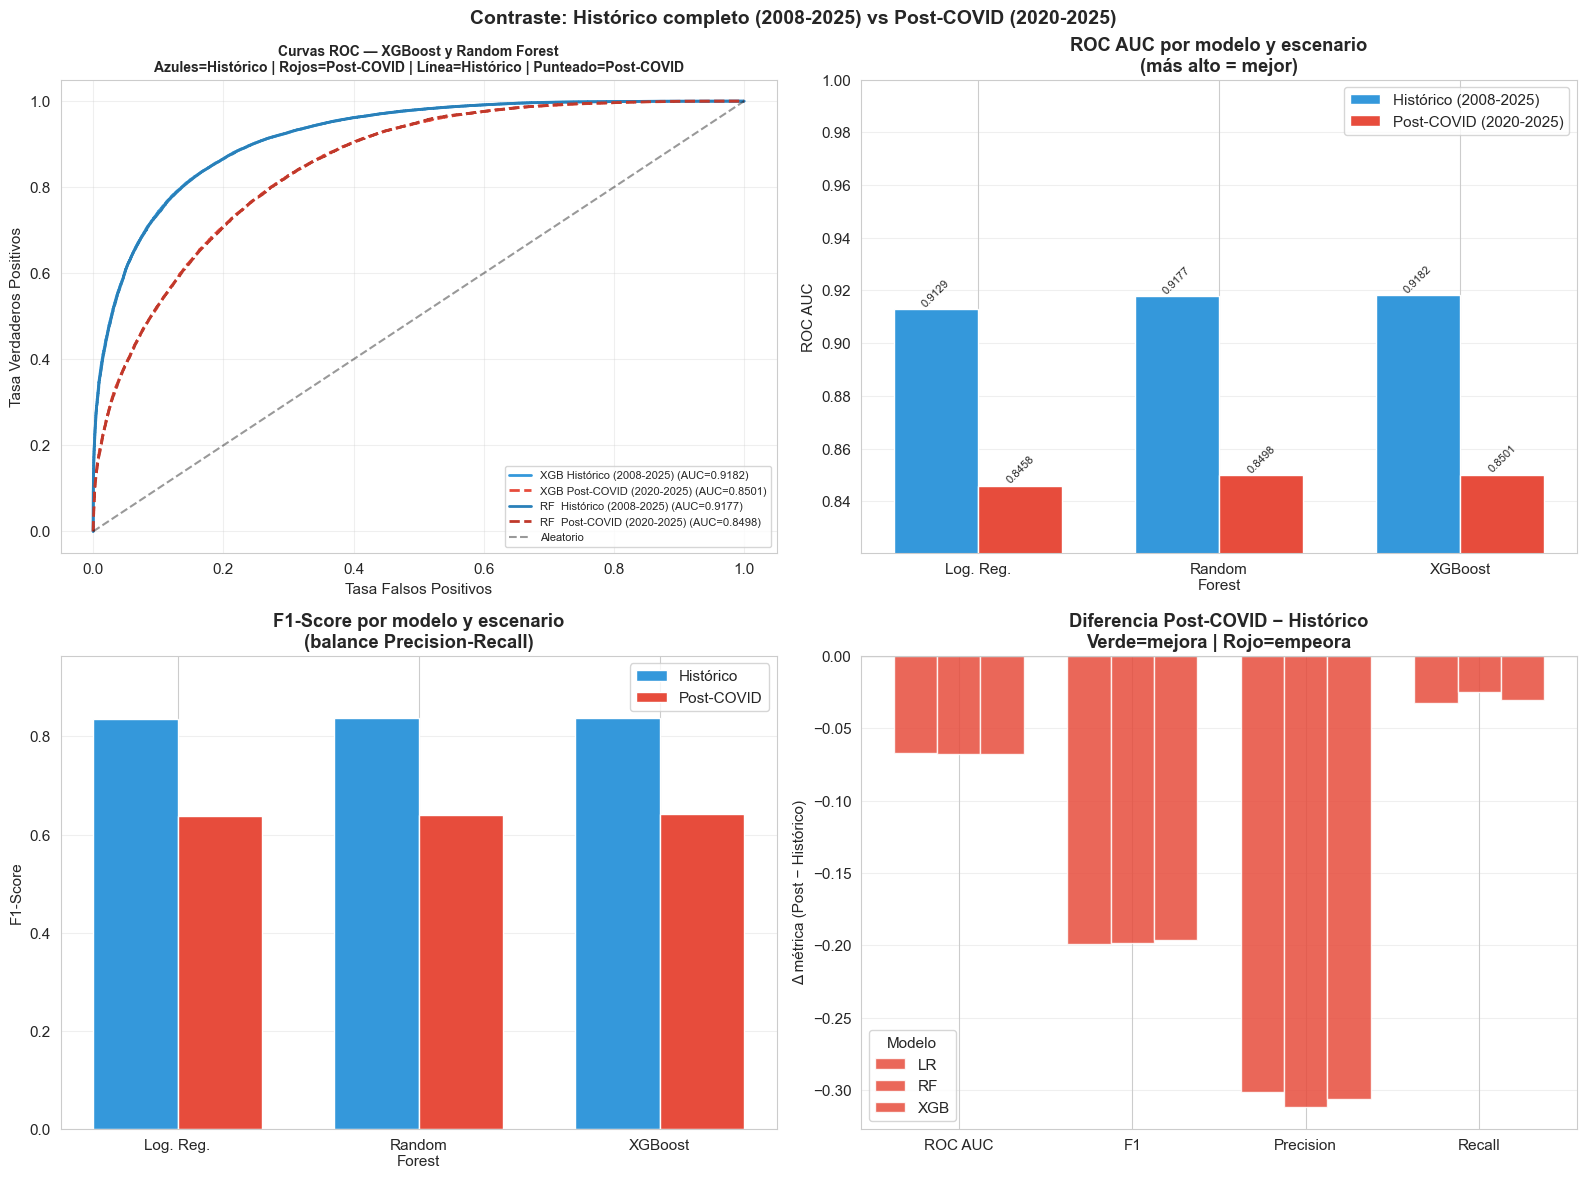

In [34]:
# ============================================================
# COMPARACIÓN DE RESULTADOS: Histórico completo vs Post-COVID
# ============================================================
print('📊 COMPARACIÓN DE RESULTADOS')
print('=' * 70)

# Tabla resumen
print(f'\n{"Modelo":<25} {"Escenario":<25} {"ROC AUC":>8} {"F1":>8} {"Precision":>10} {"Recall":>8}')
print('-' * 90)
for nom in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    mc = met_completo[nom]
    mp = met_post[nom]
    mejor_auc = '⭐' if mc['ROC AUC'] >= mp['ROC AUC'] else '  '
    print(f'{nom:<25} {"Histórico (2008-2025)":<25} {mc["ROC AUC"]:>8.4f} {mc["F1"]:>8.4f} {mc["Precision"]:>10.4f} {mc["Recall"]:>8.4f} {mejor_auc}')
    mejor_auc = '⭐' if mp['ROC AUC'] > mc['ROC AUC'] else '  '
    print(f'{"":<25} {"Post-COVID  (2020-2025)":<25} {mp["ROC AUC"]:>8.4f} {mp["F1"]:>8.4f} {mp["Precision"]:>10.4f} {mp["Recall"]:>8.4f} {mejor_auc}')
    print()

# Visualización: 4 paneles
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colores_esc = {'Histórico (2008-2025)': '#3498db', 'Post-COVID (2020-2025)': '#e74c3c'}
modelos_lista = ['Logistic Regression', 'Random Forest', 'XGBoost']
metricas_lista = ['ROC AUC', 'F1', 'Precision', 'Recall']

# Panel 1: Curvas ROC — XGBoost (mejor modelo) comparando escenarios
for nom, res, y_te_esc, col, lbl in [
    ('XGBoost', res_completo, y_te_c, '#3498db', 'XGB Histórico (2008-2025)'),
    ('XGBoost', res_post,     y_te_p, '#e74c3c', 'XGB Post-COVID (2020-2025)'),
    ('Random Forest', res_completo, y_te_c, '#2980b9', 'RF  Histórico (2008-2025)'),
    ('Random Forest', res_post,     y_te_p, '#c0392b', 'RF  Post-COVID (2020-2025)'),
]:
    fpr, tpr, _ = roc_curve(y_te_esc, res[nom]['y_proba'])
    auc_val = roc_auc_score(y_te_esc, res[nom]['y_proba'])
    style = '-' if 'Histórico' in lbl else '--'
    axes[0,0].plot(fpr, tpr, style, color=col, lw=2, label=f'{lbl} (AUC={auc_val:.4f})')
axes[0,0].plot([0,1],[0,1],'k--',alpha=0.4,label='Aleatorio')
axes[0,0].set_title('Curvas ROC — XGBoost y Random Forest\nAzules=Histórico | Rojos=Post-COVID | Línea=Histórico | Punteado=Post-COVID',
                    fontweight='bold', fontsize=10)
axes[0,0].set_xlabel('Tasa Falsos Positivos')
axes[0,0].set_ylabel('Tasa Verdaderos Positivos')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(alpha=0.3)

# Panel 2: Barras de ROC AUC por modelo y escenario
x_pos = np.arange(len(modelos_lista))
w = 0.35
aucs_c = [met_completo[m]['ROC AUC'] for m in modelos_lista]
aucs_p = [met_post[m]['ROC AUC']     for m in modelos_lista]
b1 = axes[0,1].bar(x_pos - w/2, aucs_c, w, color='#3498db', edgecolor='white', label='Histórico (2008-2025)')
b2 = axes[0,1].bar(x_pos + w/2, aucs_p, w, color='#e74c3c', edgecolor='white', label='Post-COVID (2020-2025)')
axes[0,1].set_xticks(x_pos)
axes[0,1].set_xticklabels(['Log. Reg.','Random\nForest','XGBoost'])
axes[0,1].set_ylim(min(aucs_c+aucs_p)*0.97, 1.0)
axes[0,1].set_title('ROC AUC por modelo y escenario\n(más alto = mejor)', fontweight='bold')
axes[0,1].set_ylabel('ROC AUC')
axes[0,1].legend()
axes[0,1].grid(axis='y', alpha=0.3)
for bar in list(b1)+list(b2):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                   f'{bar.get_height():.4f}', ha='center', fontsize=8, rotation=45)

# Panel 3: F1 por modelo y escenario
f1s_c = [met_completo[m]['F1'] for m in modelos_lista]
f1s_p = [met_post[m]['F1']     for m in modelos_lista]
b3 = axes[1,0].bar(x_pos - w/2, f1s_c, w, color='#3498db', edgecolor='white', label='Histórico')
b4 = axes[1,0].bar(x_pos + w/2, f1s_p, w, color='#e74c3c', edgecolor='white', label='Post-COVID')
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(['Log. Reg.','Random\nForest','XGBoost'])
axes[1,0].set_ylim(0, max(f1s_c+f1s_p)*1.15)
axes[1,0].set_title('F1-Score por modelo y escenario\n(balance Precision-Recall)', fontweight='bold')
axes[1,0].set_ylabel('F1-Score')
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

# Panel 4: Diferencia (Post - Histórico) → ¿Cuánto gana o pierde el modelo Post-COVID?
diffs = {m: {met: met_post[m][met] - met_completo[m][met] for met in metricas_lista}
         for m in modelos_lista}
x_met = np.arange(len(metricas_lista))
ww = 0.25
for i, (m, lbl_c) in enumerate(zip(modelos_lista, ['LR','RF','XGB'])):
    vals = [diffs[m][met] for met in metricas_lista]
    colores_diff = ['#2ecc71' if v >= 0 else '#e74c3c' for v in vals]
    axes[1,1].bar(x_met + (i-1)*ww, vals, ww, color=colores_diff, edgecolor='white',
                  alpha=0.85, label=lbl_c)
axes[1,1].axhline(y=0, color='black', lw=1.5, alpha=0.7)
axes[1,1].set_xticks(x_met)
axes[1,1].set_xticklabels(metricas_lista)
axes[1,1].set_title('Diferencia Post-COVID − Histórico\nVerde=mejora | Rojo=empeora', fontweight='bold')
axes[1,1].set_ylabel('Δ métrica (Post − Histórico)')
axes[1,1].legend(title='Modelo')
axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('Contraste: Histórico completo (2008-2025) vs Post-COVID (2020-2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [35]:
# ============================================================
# CONCLUSIONES DEL EXPERIMENTO
# ============================================================
print('📋 CONCLUSIONES DEL EXPERIMENTO')
print('=' * 70)

# Calcular ganancia/pérdida promedio entre escenarios
for m in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    delta_auc = met_post[m]['ROC AUC'] - met_completo[m]['ROC AUC']
    delta_f1  = met_post[m]['F1']      - met_completo[m]['F1']
    delta_rec = met_post[m]['Recall']  - met_completo[m]['Recall']
    signo_auc = '▲' if delta_auc >= 0 else '▼'
    signo_f1  = '▲' if delta_f1  >= 0 else '▼'
    print(f'  {m:<25}  AUC: {signo_auc}{abs(delta_auc):.4f}  |  F1: {signo_f1}{abs(delta_f1):.4f}  |  Recall: {"▲" if delta_rec>=0 else "▼"}{abs(delta_rec):.4f}')

# Determinar recomendación
xgb_delta = met_post['XGBoost']['ROC AUC'] - met_completo['XGBoost']['ROC AUC']
print()
print('=' * 70)
if xgb_delta > 0.005:
    print('✅ RECOMENDACIÓN: El modelo Post-COVID (2020+) es superior.')
    print('   Los datos recientes capturan mejor los patrones actuales de movilidad.')
    print('   El volumen reducido de datos no penaliza significativamente el rendimiento.')
    print('   → Usar model_df_post para producción.')
elif xgb_delta < -0.005:
    print('⚠️  RECOMENDACIÓN: El modelo Histórico completo es superior.')
    print('   El mayor volumen de datos compensa el ruido de patrones pre-COVID.')
    print('   El período 2020+ tiene insuficientes datos para generalizar bien.')
    print('   → Usar model_df_completo para producción.')
else:
    print('🔄 RESULTADO: Ambos modelos tienen rendimiento muy similar (ΔAUC < 0.005).')
    print('   Esto sugiere que los patrones espaciotemporales son estructuralmente')
    print('   estables: los mismos lugares y horas siguen siendo riesgosos.')
    print('   Sin embargo, el modelo Post-COVID es preferible para nuevas predicciones')
    print('   porque sus tasas base reflejan la realidad actual.')

print()
print('💡 INTERPRETACIÓN ADICIONAL:')
print(f'   • Datos usados en histórico: {len(model_df_completo):,} slots')
print(f'   • Datos usados en post-COVID: {len(model_df_post):,} slots ({len(model_df_post)/len(model_df_completo)*100:.1f}% del total)')
print(f'   • Si los patrones son estables: el histórico no añade mucha señal nueva')
print(f'   • Si los patrones cambiaron: el histórico introduce ruido')
print(f'   • La diferencia de AUC entre escenarios cuantifica cuánto cambió el mundo')


📋 CONCLUSIONES DEL EXPERIMENTO
  Logistic Regression        AUC: ▼0.0671  |  F1: ▼0.1989  |  Recall: ▼0.0326
  Random Forest              AUC: ▼0.0679  |  F1: ▼0.1984  |  Recall: ▼0.0252
  XGBoost                    AUC: ▼0.0680  |  F1: ▼0.1963  |  Recall: ▼0.0305

⚠️  RECOMENDACIÓN: El modelo Histórico completo es superior.
   El mayor volumen de datos compensa el ruido de patrones pre-COVID.
   El período 2020+ tiene insuficientes datos para generalizar bien.
   → Usar model_df_completo para producción.

💡 INTERPRETACIÓN ADICIONAL:
   • Datos usados en histórico: 372,960 slots
   • Datos usados en post-COVID: 371,952 slots (99.7% del total)
   • Si los patrones son estables: el histórico no añade mucha señal nueva
   • Si los patrones cambiaron: el histórico introduce ruido
   • La diferencia de AUC entre escenarios cuantifica cuánto cambió el mundo


In [ ]:
# ============================================================
# EXPORTAR MODELOS PARA LA API  (Sesión 1)
# ============================================================
import sys, pickle, numpy as np, pandas as pd
from pathlib import Path

sys.path.insert(0, 'riesgo_api')
from export_models import export_model

Path('riesgo_api/models').mkdir(parents=True, exist_ok=True)

# Modelo XGBoost — histórico completo (el mejor, AUC ~0.92)
export_model(
    model_obj  = res_completo['XGBoost']['modelo'],
    model_df_  = model_df_completo,
    city       = 'medellin',
    model_type = 'xgboost',
    metrics    = met_completo['XGBoost'],
)

# Opcional: exportar también Random Forest
# export_model(res_completo['Random Forest']['modelo'], model_df_completo,
#              'medellin', 'rf', met_completo['Random Forest'])

print('\n✅ Listo. Ahora reconstruye Docker:')
print('   cd riesgo_api && docker compose down && docker compose up --build')


In [ ]:
# ============================================================
# DEEP LEARNING: TabNet (Sesión 4)
# ============================================================
# !pip install pytorch-tabnet -q

try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    import torch
    import numpy as np
    from sklearn.metrics import roc_auc_score

    print('🧠 ENTRENAMIENTO TABNET')
    print('=' * 70)

    # El notebook histórico usa X_train / X_test / y_train / y_test
    X_tr_tn = X_train.values.astype('float32')
    X_te_tn = X_test.values.astype('float32')
    y_tr_tn = y_train.values.astype('int64')
    y_te_tn = y_test.values.astype('int64')

    pos_weight = int((y_tr_tn == 0).sum() / (y_tr_tn == 1).sum())
    print(f'scale_pos_weight: {pos_weight}')

    tabnet = TabNetClassifier(
        n_d=32, n_a=32,
        n_steps=5,
        gamma=1.3,
        n_independent=2,
        n_shared=2,
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params={'lr': 2e-3},
        scheduler_params={'step_size': 10, 'gamma': 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',
        verbose=10,
        seed=42,
    )

    tabnet.fit(
        X_train=X_tr_tn, y_train=y_tr_tn,
        eval_set=[(X_te_tn, y_te_tn)],
        eval_metric=['auc'],
        max_epochs=100,
        patience=20,
        batch_size=4096,
        weights={0: 1, 1: pos_weight},
    )

    probs_tn = tabnet.predict_proba(X_te_tn)[:, 1]
    auc_tn   = roc_auc_score(y_te_tn, probs_tn)
    auc_xgb  = met_completo['XGBoost']['ROC AUC']

    print(f'\n🎯 TabNet  ROC AUC: {auc_tn:.4f}')
    print(f'   XGBoost ROC AUC: {auc_xgb:.4f}')
    print(f'   Diferencia:      {auc_tn - auc_xgb:+.4f}')

    feat_imp = dict(zip(feature_cols, tabnet.feature_importances_))
    top_tn = sorted(feat_imp.items(), key=lambda x: x[1], reverse=True)[:10]
    print('\n🔍 Top 10 features (TabNet atención):')
    for feat, imp in top_tn:
        print(f'   {feat:<35} {imp:.4f}')

    # Exportar TabNet
    from pathlib import Path as P
    P('riesgo_api/models').mkdir(exist_ok=True)
    tabnet.save_model('riesgo_api/models/medellin_tabnet')
    print('\n✅ TabNet exportado: riesgo_api/models/medellin_tabnet.zip')

except ImportError:
    print('⚠️  pytorch-tabnet no instalado. Ejecuta: pip install pytorch-tabnet')
except Exception as e:
    import traceback; traceback.print_exc()
    print(f'❌ Error TabNet: {e}')
